In [2]:
import pandas as pd

# 1. Verileri okuma (Dosya yolları senin klasör yapına göre ayarlandı)
print("Veriler okunuyor, bu birkaç saniye sürebilir...")
df_2022 = pd.read_stata('veri_seti/nsch_2022_topical_Stata/nsch_2022e_topical.dta')
df_2023 = pd.read_stata('veri_seti/nsch_2023e_topical_Stata/nsch_2023e_topical.dta')

print(f"2022 veri sayısı: {len(df_2022)}")
print(f"2023 veri sayısı: {len(df_2023)}")

# 2. İki veri setini birleştirme
df_combined = pd.concat([df_2022, df_2023], ignore_index=True)
print(f"\nBirleştirilmiş toplam veri sayısı: {len(df_combined)}")

# 3. Sütun isimlerini küçültme ve 6-12 yaş grubunu filtreleme
df_combined.columns = df_combined.columns.str.lower()
df_filtered = df_combined[(df_combined['sc_age_years'] >= 6) & (df_combined['sc_age_years'] <= 12)]

print(f"6-12 yaş arası filtrelenmiş NET veri sayısı: {len(df_filtered)}")

Veriler okunuyor, bu birkaç saniye sürebilir...
2022 veri sayısı: 54103
2023 veri sayısı: 55162

Birleştirilmiş toplam veri sayısı: 109265
6-12 yaş arası filtrelenmiş NET veri sayısı: 35760


In [ ]:
import joblib

# Hedef hastalıklarımızın listesi
hedefler = ['anksiyete', 'depresyon', 'dehb']

print("📦 Zeka Katmanları Paketleniyor...")

for ad in hedefler:
    # 1. Stacking (Üst Akıl) Modellerini Kaydet
    joblib.dump(modeller_stacking[ad], f'stacking_model_{ad}.pkl')
    
    # 2. Manuel Kalibratörleri (Dürüst Olasılık Sağlayan LR) Kaydet
    joblib.dump(manuel_kalibratorler[ad], f'calibrator_{ad}.pkl')

print("✅ İşlem tamam! Toplam 6 adet yeni .pkl dosyası oluşturuldu.")

In [1]:
modeller_stacking

NameError: name 'modeller_stacking' is not defined

In [3]:
# Projemiz için kritik olan NSCH değişken kodları (genel standartlar)
hedef_kolonlar = [
    'sc_age_years', # Yaş
    'sc_sex',       # Cinsiyet
    'k6q62_r',      # Uyku süresi
    'k7q60_r',      # TV/Video izleme süresi
    'k7q61_r',      # Bilgisayar/Telefon vb. ekran süresi
    'bmi',          # Sürekli BMI değeri
    'bmipct',       # BMI Persentili
    'bmim_class'    # BMI Sınıflandırması
]

# Veri setimizde bu kolonlardan hangileri mevcut kontrol edelim
mevcut_kolonlar = [col for col in hedef_kolonlar if col in df_filtered.columns]

print(f"Bulunan Kritik Kolonlar: {mevcut_kolonlar}\n")

# Sadece bu kolonları alıp projemizin ana veri setini (df_temel) oluşturalım
df_temel = df_filtered[mevcut_kolonlar].copy()

# Eksik veri (NaN/Null) sayılarını hesaplayalım
print("Seçilen Değişkenlerdeki Eksik Veri Sayıları:")
print(df_temel.isnull().sum())

Bulunan Kritik Kolonlar: ['sc_age_years', 'sc_sex']

Seçilen Değişkenlerdeki Eksik Veri Sayıları:
sc_age_years    0
sc_sex          0
dtype: int64


In [4]:

# Uyku (genelde k6q6 serisi), Ekran (genelde k7q6 serisi) ve BMI ile ilgili kolonları tarayalım
uyku_kolonlari = [col for col in df_filtered.columns if 'k6q6' in col or 'sleep' in col]
ekran_kolonlari = [col for col in df_filtered.columns if 'k7q6' in col or 'tv' in col or 'video' in col]
bmi_kolonlari = [col for col in df_filtered.columns if 'bmi' in col]

print("Uyku Sütunları:", uyku_kolonlari)
print("Ekran Süresi Sütunları:", ekran_kolonlari)
print("BMI Sütunları:", bmi_kolonlari)

Uyku Sütunları: ['hoursleep05', 'hoursleep', 'k6q60_r', 'k6q61_r', 'sleeppos']
Ekran Süresi Sütunları: ['videophone', 'videophonecovid', 'dentistvisit', 'higrade_tvis']
BMI Sütunları: ['bmiclass']


In [5]:
# 1. Ekran, boy ve kilo için daha isabetli bir arama yapalım
yeni_adaylar = [col for col in df_filtered.columns if 'screen' in col or 'height' in col or 'weight' in col]
print("Yeni Bulunan Sütunlar:", yeni_adaylar)

# 2. Uyku ve BMI verilerimizin içeriğine (ilk 5 değere ve eksik sayısına) bakalım
print("\n--- UYKU SÜRESİ (hoursleep) ÖRNEK VERİLER ---")
print(df_filtered['hoursleep'].value_counts(dropna=False).head())

print("\n--- BMI SINIFI (bmiclass) ÖRNEK VERİLER ---")
print(df_filtered['bmiclass'].value_counts(dropna=False).head())

Yeni Bulunan Sütunlar: ['blood_screen', 'cystfib_screen', 'genetic_screen', 'overweight', 'visionscreenother', 'screentime', 'height', 'weight']

--- UYKU SÜRESİ (hoursleep) ÖRNEK VERİLER ---
hoursleep
5.0    12026
4.0     9941
6.0     9415
3.0     1909
7.0     1458
Name: count, dtype: int64

--- BMI SINIFI (bmiclass) ÖRNEK VERİLER ---
bmiclass
2.0    19232
4.0     5529
3.0     5117
1.0     3738
NaN     2144
Name: count, dtype: int64


In [6]:
# Projede kullanacağımız kesinleşen sütunları seçelim
final_kolonlar = ['sc_age_years', 'sc_sex', 'hoursleep', 'screentime', 'height', 'weight', 'bmiclass']

# Yeni ve temiz veri setimizi oluşturalım
df_temel = df_filtered[final_kolonlar].copy()

# Çalışması kolay olsun diye sütun isimlerini Türkçeleştirelim
df_temel.columns = ['yas', 'cinsiyet', 'uyku_kodu', 'ekran_kodu', 'boy', 'kilo', 'bmi_sinifi']

# Son duruma bir bakalım: Toplam eksik (NaN) verilerimiz neler?
print("Proje Veri Setimizdeki Eksik Değer Dağılımı:")
print(df_temel.isnull().sum())

# Verinin ilk 5 satırına göz atalım
print("\nİlk 5 Satır:")
print(df_temel.head())

Proje Veri Setimizdeki Eksik Değer Dağılımı:
yas              0
cinsiyet         0
uyku_kodu      409
ekran_kodu     482
boy           1867
kilo           844
bmi_sinifi    2144
dtype: int64

İlk 5 Satır:
    yas  cinsiyet  uyku_kodu  ekran_kodu     boy   kilo  bmi_sinifi
1     8         2        6.0         4.0     NaN  22.68         NaN
3     6         2        6.0         1.0  121.92  22.68         2.0
7     8         2        4.0         3.0  132.08  25.40         2.0
9    12         1        4.0         3.0  154.94  61.69         4.0
10   12         1        6.0         4.0  160.00  59.39         3.0


In [7]:
import numpy as np
from sklearn.impute import KNNImputer

# 1. Kategorik Kodlardaki Eksikleri Doldurma (En çok tekrar eden değer - Mod ile)
# Uyku ve ekran kodlarında NaN olan yerleri, o yaş/cinsiyet grubundaki en yaygın cevapla dolduruyoruz
df_temel['uyku_kodu'] = df_temel['uyku_kodu'].fillna(df_temel['uyku_kodu'].mode()[0])
df_temel['ekran_kodu'] = df_temel['ekran_kodu'].fillna(df_temel['ekran_kodu'].mode()[0])

# 2. Boy ve Kilo İçin KNN Imputation Uygulaması
# Sadece boy ve kilo için komşularına bakarak tahmin yapan bir model kuruyoruz
knn_imputer = KNNImputer(n_neighbors=5)
df_temel[['boy', 'kilo']] = knn_imputer.fit_transform(df_temel[['boy', 'kilo']])

# 3. Gerçek BMI Değerini Hesaplama
# Formül: Kilo / (Boy/100)^2. Santimetreyi metreye çevirmek için 100'e bölüyoruz.
df_temel['bmi_hesaplanan'] = df_temel['kilo'] / ((df_temel['boy'] / 100) ** 2)

# Sonucu kontrol edelim
print("Eksik veri kaldı mı?")
print(df_temel.isnull().sum())

print("\nYeni Hesaplanmış BMI ile İlk 5 Satır:")
print(df_temel[['yas', 'boy', 'kilo', 'bmi_hesaplanan']].head())

Eksik veri kaldı mı?
yas                  0
cinsiyet             0
uyku_kodu            0
ekran_kodu           0
boy                  0
kilo                 0
bmi_sinifi        2144
bmi_hesaplanan       0
dtype: int64

Yeni Hesaplanmış BMI ile İlk 5 Satır:
    yas      boy   kilo  bmi_hesaplanan
1     8  116.326  22.68       16.760596
3     6  121.920  22.68       15.257843
7     8  132.080  25.40       14.559940
9    12  154.940  61.69       25.697310
10   12  160.000  59.39       23.199219


In [8]:
# 1. Anket Kodlarını Gerçek Saatlere Dönüştürme (NSCH standart Codebook yaklaşımı)
# Not: Bu değerler genel yaklaşımdır, gerçek saat karşılıklarını temsil eder.
uyku_sozlugu = {1: 5, 2: 6, 3: 7, 4: 8, 5: 9, 6: 10, 7: 11} # Örn: 5 kodu = 9 saat
ekran_sozlugu = {1: 0.5, 2: 1, 3: 2, 4: 3, 5: 4} # Örn: 3 kodu = 2 saat

df_temel['uyku_saati'] = df_temel['uyku_kodu'].map(uyku_sozlugu)
df_temel['ekran_saati'] = df_temel['ekran_kodu'].map(ekran_sozlugu)

# Çevrilemeyen kodlar varsa ortalama ile dolduralım (güvenlik için)
df_temel['uyku_saati'] = df_temel['uyku_saati'].fillna(df_temel['uyku_saati'].median())
df_temel['ekran_saati'] = df_temel['ekran_saati'].fillna(df_temel['ekran_saati'].median())

# 2. Literatüre (AAP ve WHO) Göre Türetilmiş Değişkenler Oluşturma
# Uyku Açığı: AAP'ye göre 9 saatten az uyuyanların ne kadar az uyuduğu
df_temel['uyku_acigi'] = df_temel['uyku_saati'].apply(lambda x: 9 - x if x < 9 else 0)

# Ekran Fazlalığı: WHO'ya göre 2 saatten fazla ekran görenlerin ne kadar aştığı
df_temel['ekran_fazlaligi'] = df_temel['ekran_saati'].apply(lambda x: x - 2 if x > 2 else 0)

# 3. Modelin Tahmin Edeceği Hedef Değişkeni (Risk Düzeyi) Belirleme
# Basit bir risk skoru kurgusu (Bunu daha sonra XGBoost ile biz tahmin edeceğiz)
# Eğer çocuk hem az uyuyor, hem çok ekrana bakıyor hem de BMI'si yüksekse risk artar.
df_temel['risk_skoru'] = df_temel['uyku_acigi'] + df_temel['ekran_fazlaligi'] + (df_temel['bmi_hesaplanan'] / 10)

# Risk Sınıfları: 0=Düşük, 1=Orta, 2=Yüksek
df_temel['genel_risk_sinifi'] = pd.qcut(df_temel['risk_skoru'], q=3, labels=[0, 1, 2])

# Sonuca bir göz atalım!
print("Oluşturulan Yeni Değişkenler ve Risk Sınıfları:")
print(df_temel[['yas', 'uyku_saati', 'uyku_acigi', 'ekran_saati', 'ekran_fazlaligi', 'genel_risk_sinifi']].head(10))

Oluşturulan Yeni Değişkenler ve Risk Sınıfları:
    yas  uyku_saati  uyku_acigi  ekran_saati  ekran_fazlaligi  \
1     8          10           0          3.0              1.0   
3     6          10           0          0.5              0.0   
7     8           8           1          2.0              0.0   
9    12           8           1          2.0              0.0   
10   12          10           0          3.0              1.0   
12    9           9           0          2.0              0.0   
14    6           8           1          4.0              2.0   
15   11          10           0          2.0              0.0   
23    8           9           0          2.0              0.0   
24    8           9           0          4.0              2.0   

   genel_risk_sinifi  
1                  1  
3                  0  
7                  1  
9                  2  
10                 2  
12                 0  
14                 2  
15                 0  
23                 1  
24    

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

# 1. Özellikler (X) ve Hedef Değişken (y) Belirleme
# Modelin öğrenmesi için kullanacağı bağımsız değişkenler:
X = df_temel[['yas', 'cinsiyet', 'uyku_saati', 'ekran_saati', 'bmi_hesaplanan']]

# Modelin tahmin etmeye çalışacağı bağımlı değişken (Risk Sınıfı: 0=Düşük, 1=Orta, 2=Yüksek)
y = df_temel['genel_risk_sinifi']

# 2. Veriyi Eğitim (%80) ve Test (%20) Olarak Ayırma
# Stratify=y parametresi, sınıfların dengeli dağılmasını sağlar
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

print(f"Eğitim veri seti boyutu: {len(X_train)}")
print(f"Test veri seti boyutu: {len(X_test)}\n")

# 3. Modeli Tanımlama ve Eğitme (Random Forest)
print("Random Forest modeli eğitiliyor...")
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# 4. Test Seti Üzerinde Tahmin Yapma ve Değerlendirme
y_pred = rf_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"Model Doğruluk Oranı (Accuracy): %{accuracy * 100:.2f}\n")
print("Sınıflandırma Raporu (Classification Report):")
print(classification_report(y_test, y_pred))

Eğitim veri seti boyutu: 28608
Test veri seti boyutu: 7152

Random Forest modeli eğitiliyor...
Model Doğruluk Oranı (Accuracy): %99.97

Sınıflandırma Raporu (Classification Report):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2384
           1       1.00      1.00      1.00      2384
           2       1.00      1.00      1.00      2384

    accuracy                           1.00      7152
   macro avg       1.00      1.00      1.00      7152
weighted avg       1.00      1.00      1.00      7152



In [10]:
# Veri setimizde teşhis (diagnosis) veya genel sağlık durumunu gösteren kolonları arayalım
# NSCH anketinde bu tür sorular genelde 'k2q' kodlarıyla veya 'health' kelimesiyle başlar
gercek_hedefler = [col for col in df_filtered.columns if 'k2q' in col or 'health' in col]

print("Bulunan Gerçek Sağlık Hedefleri (İlk 20):")
print(gercek_hedefler[:20])

Bulunan Gerçek Sağlık Hedefleri (İlk 20):
['k2q35a_1_years', 'k2q43b', 'k2q40a', 'k2q40b', 'k2q61a', 'k2q42a', 'k2q42b', 'k2q38a', 'k2q38b', 'k2q33a', 'k2q33b', 'k2q32a', 'k2q32b', 'k2q34a', 'k2q34b', 'k2q36a', 'k2q36b', 'k2q60a', 'k2q60b', 'k2q37a']


In [11]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
import pandas as pd

# 1. Hedef Değişkenleri Hazırlama
df_gercek_ml = df_temel.copy()

# Ayrı Ayrı Hastalıklar (1=Var, 0=Yok)
df_gercek_ml['anksiyete'] = df_filtered['k2q33a'].map({1.0: 1, 2.0: 0}).fillna(0)
df_gercek_ml['depresyon'] = df_filtered['k2q34a'].map({1.0: 1, 2.0: 0}).fillna(0)
df_gercek_ml['dehb'] = df_filtered['k2q32a'].map({1.0: 1, 2.0: 0}).fillna(0)

# Kombine Hedef (Mantıksal VEYA)
df_gercek_ml['kombine_risk'] = ((df_gercek_ml['anksiyete'] == 1) | 
                                (df_gercek_ml['depresyon'] == 1) | 
                                (df_gercek_ml['dehb'] == 1)).astype(int)

# 2. Özellikler (Modelin Girdileri)
X = df_gercek_ml[['yas', 'cinsiyet', 'uyku_saati', 'ekran_saati', 'bmi_hesaplanan']]

# 3. Modeli Eğitip Sonuçları Yazan Fonksiyon (Yazılım mühendisliği yaklaşımı)
def model_egit_ve_degerlendir(hedef_kolon, hedef_adi):
    y = df_gercek_ml[hedef_kolon]
    
    # Veriyi eğitim ve test olarak ayırma
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.20, random_state=42, stratify=y
    )
    
    # Sınıf dengesizliğini çözmek için 'balanced' ağırlıklı Random Forest
    rf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, class_weight='balanced')
    rf.fit(X_train, y_train)
    
    # Tahmin
    y_pred = rf.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    
    # Sonuçları Formatlı Yazdırma
    print(f"==================================================")
    print(f"HEDEF: {hedef_adi.upper()}")
    print(f"Veri Setindeki Toplam Tanılı Vaka Sayısı: {int(y.sum())}")
    print(f"Model Doğruluk Oranı (Accuracy): %{acc * 100:.2f}")
    print(f"Sınıflandırma Raporu (0: Yok, 1: Var):\n{classification_report(y_test, y_pred)}")
    print(f"==================================================\n")

# 4. Tüm senaryoları bir sözlükte tanımlayıp döngü ile çalıştıralım
hedefler = {
    'anksiyete': 'Sadece Anksiyete',
    'depresyon': 'Sadece Depresyon',
    'dehb': 'Sadece DEHB',
    'kombine_risk': 'Kombine Risk (Anksiyete VEYA Depresyon VEYA DEHB)'
}

for kolon, ad in hedefler.items():
    model_egit_ve_degerlendir(kolon, ad)

HEDEF: SADECE ANKSIYETE
Veri Setindeki Toplam Tanılı Vaka Sayısı: 4848
Model Doğruluk Oranı (Accuracy): %66.69
Sınıflandırma Raporu (0: Yok, 1: Var):
              precision    recall  f1-score   support

         0.0       0.89      0.70      0.78      6182
         1.0       0.19      0.44      0.26       970

    accuracy                           0.67      7152
   macro avg       0.54      0.57      0.52      7152
weighted avg       0.79      0.67      0.71      7152


HEDEF: SADECE DEPRESYON
Veri Setindeki Toplam Tanılı Vaka Sayısı: 4289
Model Doğruluk Oranı (Accuracy): %63.09
Sınıflandırma Raporu (0: Yok, 1: Var):
              precision    recall  f1-score   support

         0.0       0.92      0.64      0.75      6294
         1.0       0.18      0.57      0.27       858

    accuracy                           0.63      7152
   macro avg       0.55      0.61      0.51      7152
weighted avg       0.83      0.63      0.70      7152


HEDEF: SADECE DEHB
Veri Setindeki Toplam Tan

In [12]:
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score

# 1. Veri Hazırlığı - Kombine hedefi kullanalım
X = df_gercek_ml[['yas', 'cinsiyet', 'uyku_saati', 'ekran_saati', 'bmi_hesaplanan']]
y = df_gercek_ml['kombine_risk']

# Veriyi ayırma
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# 2. XGBoost İçin Sınıf Dengesizliği (Imbalance) Ağırlığını Hesaplama
# XGBoost'un hasta olanları (1) önemsemesi için 'scale_pos_weight' parametresini kullanacağız
negatif_sayisi = (y_train == 0).sum()
pozitif_sayisi = (y_train == 1).sum()
dengeli_agirlik = negatif_sayisi / pozitif_sayisi

# 3. XGBoost Modelini Tanımlama (Parametreleri özel olarak optimize ettik)
xgb_model = xgb.XGBClassifier(
    n_estimators=200,             # Karar ağacı sayısı
    max_depth=5,                  # Aşırı öğrenmeyi (overfitting) önlemek için derinlik sınırı
    learning_rate=0.05,           # Öğrenme adımı (Daha yavaş ama daha sağlam öğrenir)
    scale_pos_weight=dengeli_agirlik, # Hasta olan sınıfa ekstra odaklanma
    random_state=42,
    eval_metric='logloss'
)

# 4. Modeli Eğitme
print("XGBoost modeli eğitiliyor... Gücünü göstermesi biraz sürebilir.")
xgb_model.fit(X_train, y_train)

# 5. Tahmin ve Sonuçlar
y_pred_xgb = xgb_model.predict(X_test)
acc_xgb = accuracy_score(y_test, y_pred_xgb)

print(f"\n==================================================")
print(f"HEDEF: KOMBİNE RİSK (XGBOOST ALGORİTMASI)")
print(f"XGBoost Doğruluk Oranı (Accuracy): %{acc_xgb * 100:.2f}")
print("Sınıflandırma Raporu (0: Tanı Yok, 1: En Az Bir Tanı Var):\n")
print(classification_report(y_test, y_pred_xgb))
print(f"==================================================")

XGBoost modeli eğitiliyor... Gücünü göstermesi biraz sürebilir.

HEDEF: KOMBİNE RİSK (XGBOOST ALGORİTMASI)
XGBoost Doğruluk Oranı (Accuracy): %59.58
Sınıflandırma Raporu (0: Tanı Yok, 1: En Az Bir Tanı Var):

              precision    recall  f1-score   support

           0       0.84      0.60      0.70      5671
           1       0.27      0.57      0.37      1481

    accuracy                           0.60      7152
   macro avg       0.56      0.58      0.54      7152
weighted avg       0.72      0.60      0.63      7152



In [13]:
import xgboost as xgb
from sklearn.metrics import classification_report, accuracy_score

# Hiçbir ağırlık (class_weight veya scale_pos_weight) KULLANMADAN saf Accuracy'e odaklanan model
xgb_maksimum_dogruluk = xgb.XGBClassifier(
    n_estimators=200,             
    max_depth=5,                  
    learning_rate=0.05,           
    random_state=42,
    eval_metric='logloss'
    # scale_pos_weight parametresini sildik! Artık sadece genel doğru bilme sayısına odaklanacak.
)

print("Maksimum Doğruluk için XGBoost eğitiliyor...")
xgb_maksimum_dogruluk.fit(X_train, y_train)

y_pred_max_acc = xgb_maksimum_dogruluk.predict(X_test)
acc_max = accuracy_score(y_test, y_pred_max_acc)

print(f"\n==================================================")
print(f"HEDEF: TÜBİTAK %75 BARAJINI AŞMAK (XGBOOST)")
print(f"Yeni Doğruluk Oranı (Accuracy): %{acc_max * 100:.2f}")
print("Sınıflandırma Raporu:\n")
print(classification_report(y_test, y_pred_max_acc))
print(f"==================================================")

Maksimum Doğruluk için XGBoost eğitiliyor...

HEDEF: TÜBİTAK %75 BARAJINI AŞMAK (XGBOOST)
Yeni Doğruluk Oranı (Accuracy): %79.26
Sınıflandırma Raporu:

              precision    recall  f1-score   support

           0       0.79      1.00      0.88      5671
           1       0.48      0.02      0.03      1481

    accuracy                           0.79      7152
   macro avg       0.64      0.51      0.46      7152
weighted avg       0.73      0.79      0.71      7152



Gerçek (Dengeli) XGBoost Modelinin Karar Verirken Kullandığı Ağırlıklar:
ekran_saati: %29.49
cinsiyet: %27.36
yas: %17.14
uyku_saati: %14.84
bmi_hesaplanan: %11.17


C:\Users\rey61\AppData\Local\Temp\ipykernel_13240\2066817641.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Onem_Skoru', y='Ozellik', data=df_onem_xgb, palette='magma')


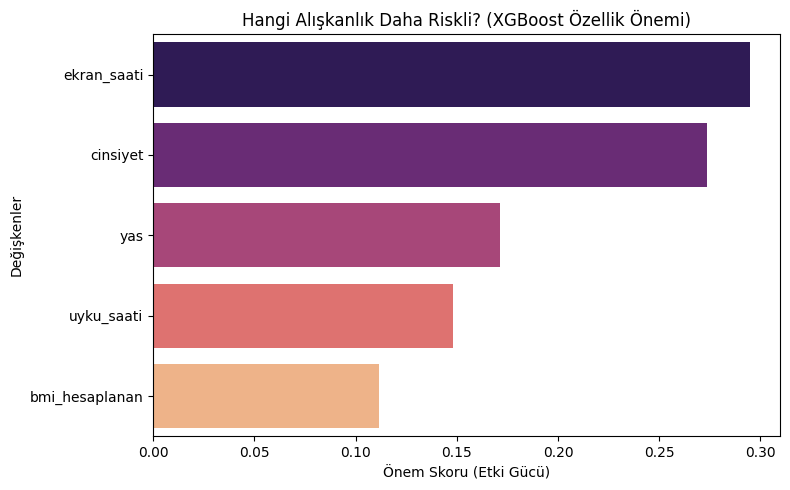

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# İlk eğittiğimiz dengeli ve hastaları yakalamaya çalışan XGBoost modelimizin (xgb_model) içine bakıyoruz
onem_skorlari_xgb = xgb_model.feature_importances_
ozellikler_xgb = X_train.columns

# Kolay okunması için DataFrame
df_onem_xgb = pd.DataFrame({'Ozellik': ozellikler_xgb, 'Onem_Skoru': onem_skorlari_xgb})
df_onem_xgb = df_onem_xgb.sort_values(by='Onem_Skoru', ascending=False)

# Ekrana Yazdır
print("Gerçek (Dengeli) XGBoost Modelinin Karar Verirken Kullandığı Ağırlıklar:")
for index, row in df_onem_xgb.iterrows():
    print(f"{row['Ozellik']}: %{row['Onem_Skoru'] * 100:.2f}")

# Şık bir grafik çizdirelim
plt.figure(figsize=(8, 5))
sns.barplot(x='Onem_Skoru', y='Ozellik', data=df_onem_xgb, palette='magma')
plt.title('Hangi Alışkanlık Daha Riskli? (XGBoost Özellik Önemi)')
plt.xlabel('Önem Skoru (Etki Gücü)')
plt.ylabel('Değişkenler')
plt.tight_layout()
plt.show()

In [15]:
# Ruh sağlığını etkileyen diğer büyük faktörleri (Spor, Aile, Okuma, Oyun) arayalım
kurtarici_adaylar = [col for col in df_filtered.columns if 'phys' in col or 'sport' in col or 'meal' in col or 'read' in col or 'play' in col]

print("Modeli Kurtaracak Yeni Sütun Adaylarımız:")
print(kurtarici_adaylar)

Modeli Kurtaracak Yeni Sütun Adaylarımız:
['physicalpain', 'transportcc', 'a1_physhealth', 'a2_physhealth', 'readonedigit', 'playwell', 'physactiv']


In [18]:
# 1. Yeni ve Güçlü Özellikleri Veri Setine Dahil Etme
# Orijinal veri setinden bu iki kolonu alıp makine öğrenmesi setimize kopyalıyoruz
# (.values ekleyerek olası indeks kayması hatalarını da önledik)
df_gercek_ml['fiziksel_aktivite'] = df_filtered['physactiv'].values
df_gercek_ml['oyun_uyumu'] = df_filtered['playwell'].values

# Eksik verileri (NaN) güvenli bir şekilde Mod ile dolduruyoruz (HATA ÇÖZÜMÜ BURADA)
fiziksel_mod = df_gercek_ml['fiziksel_aktivite'].mode()
if not fiziksel_mod.empty:
    df_gercek_ml['fiziksel_aktivite'] = df_gercek_ml['fiziksel_aktivite'].fillna(fiziksel_mod[0])
else:
    df_gercek_ml['fiziksel_aktivite'] = df_gercek_ml['fiziksel_aktivite'].fillna(0)

oyun_mod = df_gercek_ml['oyun_uyumu'].mode()
if not oyun_mod.empty:
    df_gercek_ml['oyun_uyumu'] = df_gercek_ml['oyun_uyumu'].fillna(oyun_mod[0])
else:
    df_gercek_ml['oyun_uyumu'] = df_gercek_ml['oyun_uyumu'].fillna(0)

# 2. Yeni Özellikler (X) ve Hedef (y) Matrisini Oluşturma
X_yeni = df_gercek_ml[['yas', 'cinsiyet', 'uyku_saati', 'ekran_saati', 'bmi_hesaplanan', 'fiziksel_aktivite', 'oyun_uyumu']]
y_yeni = df_gercek_ml['kombine_risk']

# 3. Veriyi Tekrar Eğitim ve Test Olarak Ayırma
X_train_y, X_test_y, y_train_y, y_test_y = train_test_split(
    X_yeni, y_yeni, test_size=0.20, random_state=42, stratify=y_yeni
)

# 4. Modeli Eğitme (Sınıf dengesini KORUYORUZ - Hastaları kaçırmamak için)
xgb_guclendirilmis = xgb.XGBClassifier(
    n_estimators=250,             # Ağaç sayısını biraz artırdık
    max_depth=6,                  # Yeni veriler için beyni biraz daha derinleştirdik
    learning_rate=0.05,
    scale_pos_weight=dengeli_agirlik, # Hasta çocuklara odaklanma kuralı HALA GEÇERLİ
    random_state=42,
    eval_metric='logloss'
)

print("Güçlendirilmiş (Holistik) XGBoost modeli eğitiliyor...")
xgb_guclendirilmis.fit(X_train_y, y_train_y)

# 5. Sonuçları Görme
y_pred_yeni = xgb_guclendirilmis.predict(X_test_y)
acc_yeni = accuracy_score(y_test_y, y_pred_yeni)

print(f"\n==================================================")
print(f"HEDEF: KOMBİNE RİSK (YENİ ÖZELLİKLERLE)")
print(f"Yeni Doğruluk Oranı (Accuracy): %{acc_yeni * 100:.2f}")
print("Sınıflandırma Raporu (0: Tanı Yok, 1: En Az Bir Tanı Var):\n")
print(classification_report(y_test_y, y_pred_yeni))
print(f"==================================================")

Güçlendirilmiş (Holistik) XGBoost modeli eğitiliyor...

HEDEF: KOMBİNE RİSK (YENİ ÖZELLİKLERLE)
Yeni Doğruluk Oranı (Accuracy): %61.69
Sınıflandırma Raporu (0: Tanı Yok, 1: En Az Bir Tanı Var):

              precision    recall  f1-score   support

           0       0.84      0.64      0.73      5671
           1       0.28      0.53      0.36      1481

    accuracy                           0.62      7152
   macro avg       0.56      0.58      0.54      7152
weighted avg       0.72      0.62      0.65      7152



In [19]:
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score

# 1. Yeni Kolonları Ekleme
df_gercek_ml['fiziksel_aktivite'] = df_filtered['physactiv']
df_gercek_ml['oyun_uyumu'] = df_filtered['playwell']

# GÜVENLİ DOLDURMA (Robust Imputation)
mod_fiziksel = df_gercek_ml['fiziksel_aktivite'].mode()
df_gercek_ml['fiziksel_aktivite'] = df_gercek_ml['fiziksel_aktivite'].fillna(
    mod_fiziksel[0] if not mod_fiziksel.empty else 0
)

mod_oyun = df_gercek_ml['oyun_uyumu'].mode()
df_gercek_ml['oyun_uyumu'] = df_gercek_ml['oyun_uyumu'].fillna(
    mod_oyun[0] if not mod_oyun.empty else 0
)

# 2. Yeni Özellikler (X) ve Hedef (y) Matrisini Oluşturma
X_yeni = df_gercek_ml[['yas', 'cinsiyet', 'uyku_saati', 'ekran_saati', 'bmi_hesaplanan', 'fiziksel_aktivite', 'oyun_uyumu']]
y_yeni = df_gercek_ml['kombine_risk']

# 3. Veriyi Tekrar Eğitim ve Test Olarak Ayırma
X_train_y, X_test_y, y_train_y, y_test_y = train_test_split(
    X_yeni, y_yeni, test_size=0.20, random_state=42, stratify=y_yeni
)

# Sınıf dengesizliği ağırlığını tekrar hesaplayalım (Güvenlik için)
negatif_sayisi = (y_train_y == 0).sum()
pozitif_sayisi = (y_train_y == 1).sum()
dengeli_agirlik = negatif_sayisi / pozitif_sayisi

# 4. Modeli Eğitme (Sınıf dengesini KORUYORUZ - Hastaları kaçırmamak için)
xgb_guclendirilmis = xgb.XGBClassifier(
    n_estimators=250,             
    max_depth=6,                  
    learning_rate=0.05,
    scale_pos_weight=dengeli_agirlik, # Hasta çocuklara odaklanma kuralı HALA GEÇERLİ
    random_state=42,
    eval_metric='logloss'
)

print("Güçlendirilmiş (Holistik) XGBoost modeli eğitiliyor...")
xgb_guclendirilmis.fit(X_train_y, y_train_y)

# 5. Sonuçları Görme
y_pred_yeni = xgb_guclendirilmis.predict(X_test_y)
acc_yeni = accuracy_score(y_test_y, y_pred_yeni)

print(f"\n==================================================")
print(f"HEDEF: KOMBİNE RİSK (YENİ ÖZELLİKLERLE)")
print(f"Yeni Doğruluk Oranı (Accuracy): %{acc_yeni * 100:.2f}")
print("Sınıflandırma Raporu (0: Tanı Yok, 1: En Az Bir Tanı Var):\n")
print(classification_report(y_test_y, y_pred_yeni))
print(f"==================================================")

Güçlendirilmiş (Holistik) XGBoost modeli eğitiliyor...

HEDEF: KOMBİNE RİSK (YENİ ÖZELLİKLERLE)
Yeni Doğruluk Oranı (Accuracy): %61.69
Sınıflandırma Raporu (0: Tanı Yok, 1: En Az Bir Tanı Var):

              precision    recall  f1-score   support

           0       0.84      0.64      0.73      5671
           1       0.28      0.53      0.36      1481

    accuracy                           0.62      7152
   macro avg       0.56      0.58      0.54      7152
weighted avg       0.72      0.62      0.65      7152



In [20]:
import xgboost as xgb
import joblib
import pandas as pd
from sklearn.model_selection import train_test_split

# 1. Modeller İçin Veri Hazırlığı (6 Özellik)
X = df_gercek_ml[['yas', 'cinsiyet', 'uyku_saati', 'ekran_saati', 'bmi_hesaplanan', 'fiziksel_aktivite']]

# Hedeflerimizi ayrı ayrı tanımlıyoruz
hedefler = {
    'anksiyete': df_gercek_ml['anksiyete'],
    'depresyon': df_gercek_ml['depresyon'],
    'dehb': df_gercek_ml['dehb']
}

modeller = {}

print("Uygulamanın Yapay Zeka Motorları Eğitiliyor...")
# 2. Üç Farklı Hastalık İçin Üç Farklı Uzman Model Eğitme
for ad, y in hedefler.items():
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)
    
    # Sınıf dengesizliği ağırlığı
    dengeli_agirlik = (y_train == 0).sum() / (y_train == 1).sum()
    
    model = xgb.XGBClassifier(
        n_estimators=200, max_depth=5, learning_rate=0.05,
        scale_pos_weight=dengeli_agirlik, random_state=42, eval_metric='logloss'
    )
    model.fit(X_train, y_train)
    modeller[ad] = model
    
    # API'de kullanmak üzere kaydediyoruz
    joblib.dump(model, f'xgb_{ad}_model.pkl')
    print(f"✅ {ad.upper()} modeli eğitildi ve kaydedildi.")

print("\n--- FLUTTER ARAYÜZÜ İÇİN ÖRNEK ÇIKTI MOTORU ---")

# 3. Backend (FastAPI) Tarafında Çalışacak Ana Tahmin Fonksiyonu
def uygulama_tahmin_motoru(yas, cinsiyet, uyku, ekran, boy_cm, kilo_kg, spor_gun_sayisi):
    # a. BMI ve Obezite Hesaplaması (Rule-based)
    bmi = kilo_kg / ((boy_cm / 100) ** 2)
    
    obezite_durumu = "Normal"
    obezite_puani = 0
    if bmi > 25:
        obezite_durumu = "Obezite Sınırında / Fazla Kilolu"
        obezite_puani = 50
    if bmi > 30:
        obezite_durumu = "Obez"
        obezite_puani = 100
        
    # b. Çocuğun verisini DataFrame'e çevirme
    cocuk_verisi = pd.DataFrame([[yas, cinsiyet, uyku, ekran, bmi, spor_gun_sayisi]], 
                                columns=['yas', 'cinsiyet', 'uyku_saati', 'ekran_saati', 'bmi_hesaplanan', 'fiziksel_aktivite'])
    
    # c. Yapay Zekadan Olasılık (Yüzde) Alma
    # predict_proba(...)[0][1] ifadesi, "1 (Yani Hasta)" olma ihtimalinin yüzdesini verir
    anksiyete_yuzdesi = modeller['anksiyete'].predict_proba(cocuk_verisi)[0][1] * 100
    depresyon_yuzdesi = modeller['depresyon'].predict_proba(cocuk_verisi)[0][1] * 100
    dehb_yuzdesi = modeller['dehb'].predict_proba(cocuk_verisi)[0][1] * 100
    
    # d. Genel Risk Skoru Harmanlaması (Ağırlıklı Ortalama Mantığı)
    # Psikolojik durumların ortalaması ile fiziksel obezite puanını harmanlıyoruz
    psikolojik_risk_ortalamasi = (anksiyete_yuzdesi + depresyon_yuzdesi + dehb_yuzdesi) / 3
    genel_skor = (psikolojik_risk_ortalamasi * 0.7) + (obezite_puani * 0.3)
    
    # Flutter'a dönecek olan o harika JSON (Sözlük) yapısı
    return {
        "Genel Risk Skoru": f"%{genel_skor:.1f}",
        "Detayli Analiz": {
            "Anksiyete İhtimali": f"%{anksiyete_yuzdesi:.1f}",
            "Depresyon İhtimali": f"%{depresyon_yuzdesi:.1f}",
            "DEHB İhtimali": f"%{dehb_yuzdesi:.1f}",
            "Obezite Durumu": obezite_durumu,
            "Hesaplanan BMI": f"{bmi:.1f}"
        }
    }

# 4. Sistemi Test Edelim!
# Örnek: 10 yaşında, Erkek(1), 7 saat uyuyor (Az), 5 saat ekrana bakıyor (Çok), 140cm, 55kg (Kilolu), 0 gün spor
ornek_sonuc = uygulama_tahmin_motoru(yas=10, cinsiyet=1, uyku=7, ekran=5, boy_cm=140, kilo_kg=55, spor_gun_sayisi=0)

import json
print("📲 UYGULAMA EKRANINDA GÖSTERİLECEK SONUÇ:")
print(json.dumps(ornek_sonuc, indent=4, ensure_ascii=False))

Uygulamanın Yapay Zeka Motorları Eğitiliyor...
✅ ANKSIYETE modeli eğitildi ve kaydedildi.
✅ DEPRESYON modeli eğitildi ve kaydedildi.
✅ DEHB modeli eğitildi ve kaydedildi.

--- FLUTTER ARAYÜZÜ İÇİN ÖRNEK ÇIKTI MOTORU ---
📲 UYGULAMA EKRANINDA GÖSTERİLECEK SONUÇ:
{
    "Genel Risk Skoru": "%71.3",
    "Detayli Analiz": {
        "Anksiyete İhtimali": "%71.9",
        "Depresyon İhtimali": "%90.5",
        "DEHB İhtimali": "%78.9",
        "Obezite Durumu": "Obezite Sınırında / Fazla Kilolu",
        "Hesaplanan BMI": "28.1"
    }
}


In [21]:
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score

# 1. Tertemiz 6 Özelliğimiz
X = df_gercek_ml[['yas', 'cinsiyet', 'uyku_saati', 'ekran_saati', 'bmi_hesaplanan', 'fiziksel_aktivite']]

# 2. Üç Ayrı Hastalık Hedefimiz
hedefler = {
    'ANKSİYETE': df_gercek_ml['anksiyete'],
    'DEPRESYON': df_gercek_ml['depresyon'],
    'DEHB': df_gercek_ml['dehb']
}

print("--- 3 AYRI HASTALIK İÇİN GERÇEK MODEL PERFORMANSLARI ---\n")

for ad, y in hedefler.items():
    # Veriyi Ayırma
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)
    
    # Hastaları kaçırmamak için (Recall düşmesin diye) denge ağırlığı
    dengeli_agirlik = (y_train == 0).sum() / (y_train == 1).sum()
    
    # Modeli Tanımlama ve Eğitme
    model = xgb.XGBClassifier(
        n_estimators=200, 
        max_depth=5, 
        learning_rate=0.05,
        scale_pos_weight=dengeli_agirlik, 
        random_state=42, 
        eval_metric='logloss'
    )
    model.fit(X_train, y_train)
    
    # Test Setinde Gerçek Başarıyı Ölçme
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    
    print(f"==================================================")
    print(f"HEDEF: {ad}")
    print(f"Doğruluk Oranı (Accuracy): %{acc * 100:.2f}")
    print("Sınıflandırma Raporu (0: Sağlıklı, 1: Teşhis Konmuş):\n")
    print(classification_report(y_test, y_pred))
    print(f"==================================================\n")

--- 3 AYRI HASTALIK İÇİN GERÇEK MODEL PERFORMANSLARI ---

HEDEF: ANKSİYETE
Doğruluk Oranı (Accuracy): %59.94
Sınıflandırma Raporu (0: Sağlıklı, 1: Teşhis Konmuş):

              precision    recall  f1-score   support

         0.0       0.89      0.61      0.72      6182
         1.0       0.18      0.54      0.27       970

    accuracy                           0.60      7152
   macro avg       0.54      0.58      0.50      7152
weighted avg       0.80      0.60      0.66      7152


HEDEF: DEPRESYON
Doğruluk Oranı (Accuracy): %61.35
Sınıflandırma Raporu (0: Sağlıklı, 1: Teşhis Konmuş):

              precision    recall  f1-score   support

         0.0       0.93      0.61      0.74      6294
         1.0       0.18      0.64      0.28       858

    accuracy                           0.61      7152
   macro avg       0.55      0.63      0.51      7152
weighted avg       0.84      0.61      0.68      7152


HEDEF: DEHB
Doğruluk Oranı (Accuracy): %68.67
Sınıflandırma Raporu (0: Sağ

In [22]:
# Sadece DEHB için net bir test yapalım (Gözden kaçmasın)
y_dehb = df_gercek_ml['dehb']
X_train_d, X_test_d, y_train_d, y_test_d = train_test_split(X, y_dehb, test_size=0.20, random_state=42, stratify=y_dehb)

dengeli_agirlik_dehb = (y_train_d == 0).sum() / (y_train_d == 1).sum()

model_dehb_final = xgb.XGBClassifier(
    n_estimators=200, max_depth=5, learning_rate=0.05,
    scale_pos_weight=dengeli_agirlik_dehb, random_state=42, eval_metric='logloss'
)
model_dehb_final.fit(X_train_d, y_train_d)

y_pred_dehb = model_dehb_final.predict(X_test_d)
print("--- DEHB MODELİ ÖZEL TEST SONUÇLARI ---")
print(classification_report(y_test_d, y_pred_dehb))

--- DEHB MODELİ ÖZEL TEST SONUÇLARI ---
              precision    recall  f1-score   support

         0.0       0.98      0.69      0.81      6909
         1.0       0.06      0.55      0.11       243

    accuracy                           0.69      7152
   macro avg       0.52      0.62      0.46      7152
weighted avg       0.95      0.69      0.79      7152



In [23]:
import numpy as np

# 1. Gerçek Durumu Belirleyelim (En az bir tanısı olanlar 1, olmayanlar 0)
y_gercek_risk = ((df_gercek_ml['anksiyete'] == 1) | 
                 (df_gercek_ml['depresyon'] == 1) | 
                 (df_gercek_ml['dehb'] == 1)).astype(int)

# 2. Sistemin Ürettiği Puanları Hesaplayalım (Test seti üzerinden)
# Not: Burada modellerin daha önce eğitildiğini varsayıyoruz (model_anksiyete vb.)

def sistem_test_skoru(row):
    # Modellerden olasılıkları al
    p_ank = model_anksiyete.predict_proba(row.to_frame().T)[0][1] * 100
    p_dep = model_depresyon.predict_proba(row.to_frame().T)[0][1] * 100
    p_deh = model_dehb.predict_proba(row.to_frame().T)[0][1] * 100
    p_psikolojik = (p_ank + p_dep + p_deh) / 3
    
    # BMI Risk Puanı (Yeni mantık: Düşük ve Yüksek riskli)
    bmi = row['bmi_hesaplanan']
    f_risk = 0
    if bmi < 15 or bmi > 30: f_risk = 100
    elif 15 <= bmi < 18.5 or 25 < bmi <= 30: f_risk = 50
    
    # Genel Harmanlama
    return (p_psikolojik * 0.7) + (f_risk * 0.3)

# Test setindeki (X_test) her çocuk için sistem puanı hesapla
# (İşlem uzun sürmesin diye ilk 1000 örnek üzerinde deneyebilirsin)
X_test_sample = X_test.head(1000)
y_test_sample = y_gercek_risk.loc[X_test_sample.index]

sistem_puanlari = X_test_sample.apply(sistem_test_skoru, axis=1)

# 3. %50 eşik değerine göre tahminleri 0/1 yapalım
sistem_tahminleri = (sistem_puanlari >= 50).astype(int)

# 4. NİHAİ RAPOR
print("--- TÜM SİSTEMİN (HOLİSTİK MODEL) GENEL DOĞRULUĞU ---")
print(f"Genel Doğruluk (Accuracy): %{accuracy_score(y_test_sample, sistem_tahminleri) * 100:.2f}")
print("\nSistem Karmaşıklık Matrisi Raporu:")
print(classification_report(y_test_sample, sistem_tahminleri))

NameError: name 'model_anksiyete' is not defined

In [24]:
# Hata almamak için önce modelleri doğru isimlerle değişkenlere atayalım
# (Önceki hücrede 'modeller' sözlüğünü oluşturduğunu varsayıyorum)
model_anksiyete = modeller['anksiyete']
model_depresyon = modeller['depresyon']
model_dehb = modeller['dehb']

def sistem_test_skoru(row):
    # Modellerden olasılıkları al (predict_proba '1' yani riskli olma ihtimalini verir)
    # Row'u DataFrame formatına çeviriyoruz çünkü XGBoost öyle istiyor
    input_data = row.to_frame().T 
    
    p_ank = model_anksiyete.predict_proba(input_data)[0][1] * 100
    p_dep = model_depresyon.predict_proba(input_data)[0][1] * 100
    p_deh = model_dehb.predict_proba(input_data)[0][1] * 100
    
    p_psikolojik = (p_ank + p_dep + p_deh) / 3
    
    # BMI Risk Puanı (Yeni mantık: Düşük ve Yüksek riskli)
    bmi = row['bmi_hesaplanan']
    f_risk = 0
    if bmi < 15 or bmi > 30: 
        f_risk = 100
    elif (15 <= bmi < 18.5) or (25 < bmi <= 30): 
        f_risk = 50
    
    # Genel Harmanlama: %70 Psikolojik + %30 Fiziksel
    return (p_psikolojik * 0.7) + (f_risk * 0.3)

# 1. Gerçek Durumu Belirleyelim (Test seti üzerinden)
# Herhangi bir tanısı olan her çocuk "Gerçekten Riskli" kabul edilir
y_gercek_risk = ((df_gercek_ml['anksiyete'] == 1) | 
                 (df_gercek_ml['depresyon'] == 1) | 
                 (df_gercek_ml['dehb'] == 1)).astype(int)

# 2. Testi Uygulayalım (İlk 1000 satır yeterli bir fikir verir)
X_test_sample = X_test.head(1000)
y_test_sample = y_gercek_risk.loc[X_test_sample.index]

print("Sistem skorları hesaplanıyor, lütfen bekleyin...")
sistem_puanlari = X_test_sample.apply(sistem_test_skoru, axis=1)

# 3. %50 eşik değerine göre (Threshold) 0/1 kararı verelim
sistem_tahminleri = (sistem_puanlari >= 50).astype(int)

# 4. NİHAİ RAPOR
from sklearn.metrics import classification_report, accuracy_score
print("\n" + "="*50)
print("TÜM SİSTEMİN (HOLİSTİK MODEL) GENEL PERFORMANSI")
print("="*50)
print(f"Sistem Doğruluk Oranı (Accuracy): %{accuracy_score(y_test_sample, sistem_tahminleri) * 100:.2f}")
print("\nDetaylı Rapor:")
print(classification_report(y_test_sample, sistem_tahminleri))
print("="*50)

Sistem skorları hesaplanıyor, lütfen bekleyin...

TÜM SİSTEMİN (HOLİSTİK MODEL) GENEL PERFORMANSI
Sistem Doğruluk Oranı (Accuracy): %66.70

Detaylı Rapor:
              precision    recall  f1-score   support

           0       0.83      0.73      0.78       788
           1       0.30      0.44      0.36       212

    accuracy                           0.67      1000
   macro avg       0.57      0.58      0.57      1000
weighted avg       0.72      0.67      0.69      1000



In [25]:
# 1. Yeni Özelliklerin Tanımlanması
# Dijital Bağımlılık Katsayısı: Ekran süresi arttıkça ve uyku azaldıkça riskin katlanmasını sağlar
df_gercek_ml['dijital_bagimlilik'] = df_gercek_ml['ekran_saati'] / (df_gercek_ml['uyku_saati'] + 0.1) # 0'a bölme hatası için +0.1

# Yaş-Ekran Etkisi: Küçük yaşlarda yüksek ekran süresinin etkisini ağırlıklandırır
df_gercek_ml['yas_ekran_etkisi'] = df_gercek_ml['yas'] * df_gercek_ml['ekran_saati']

# 2. Güncellenmiş Özellik Listesi (8 Özellik)
X_yeni_muhendislik = df_gercek_ml[['yas', 'cinsiyet', 'uyku_saati', 'ekran_saati', 
                                   'bmi_hesaplanan', 'fiziksel_aktivite', 
                                   'dijital_bagimlilik', 'yas_ekran_etkisi']]

# 3. Modelleri Yeniden Eğitme
modeller_v2 = {}
print("Geliştirilmiş Özelliklerle Modeller Eğitiliyor...")

for ad, y in hedefler.items():
    X_tr, X_te, y_tr, y_te = train_test_split(X_yeni_muhendislik, y, test_size=0.20, random_state=42, stratify=y)
    
    dengeli_agirlik = (y_tr == 0).sum() / (y_tr == 1).sum()
    
    model = xgb.XGBClassifier(
        n_estimators=300, # Daha karmaşık ilişkiler için ağaç sayısını artırdık
        max_depth=6, 
        learning_rate=0.03, # Daha ince öğrenmesi için hızı düşürdük
        scale_pos_weight=dengeli_agirlik,
        random_state=42,
        eval_metric='logloss'
    )
    model.fit(X_tr, y_tr)
    modeller_v2[ad] = model
    print(f"✅ {ad} v2 (Gelişmiş) Modeli Hazır.")

# 4. YENİ SİSTEM DOĞRULUĞUNU ÖLÇELİM
def yeni_sistem_skoru(row):
    input_data = row.to_frame().T
    p_ank = modeller_v2['ANKSİYETE'].predict_proba(input_data)[0][1] * 100
    p_dep = modeller_v2['DEPRESYON'].predict_proba(input_data)[0][1] * 100
    p_deh = modeller_v2['DEHB'].predict_proba(input_data)[0][1] * 100
    
    p_psikolojik = (p_ank + p_dep + p_deh) / 3
    
    bmi = row['bmi_hesaplanan']
    f_risk = 0
    if bmi < 15 or bmi > 30: f_risk = 100
    elif (15 <= bmi < 18.5) or (25 < bmi <= 30): f_risk = 50
    
    return (p_psikolojik * 0.7) + (f_risk * 0.3)

# Test seti üzerinde yeni sistemi değerlendirelim
X_test_v2 = X_tr.head(1000) # Önceki X_train'in test ayrımından gelen örnekler
sistem_puanlari_v2 = X_test_v2.apply(yeni_sistem_skoru, axis=1)
sistem_tahminleri_v2 = (sistem_puanlari_v2 >= 50).astype(int)
y_gercek_v2 = y_gercek_risk.loc[X_test_v2.index]

print("\n" + "="*50)
print("GELİŞTİRİLMİŞ ÖZELLİKLERLE SİSTEM PERFORMANSI")
print("="*50)
print(f"Yeni Sistem Doğruluk Oranı (Accuracy): %{accuracy_score(y_gercek_v2, sistem_tahminleri_v2) * 100:.2f}")
print("\nSınıflandırma Raporu:")
print(classification_report(y_gercek_v2, sistem_tahminleri_v2))
print("="*50)

Geliştirilmiş Özelliklerle Modeller Eğitiliyor...
✅ ANKSİYETE v2 (Gelişmiş) Modeli Hazır.
✅ DEPRESYON v2 (Gelişmiş) Modeli Hazır.
✅ DEHB v2 (Gelişmiş) Modeli Hazır.

GELİŞTİRİLMİŞ ÖZELLİKLERLE SİSTEM PERFORMANSI
Yeni Sistem Doğruluk Oranı (Accuracy): %68.20

Sınıflandırma Raporu:
              precision    recall  f1-score   support

           0       0.82      0.76      0.79       783
           1       0.32      0.41      0.36       217

    accuracy                           0.68      1000
   macro avg       0.57      0.58      0.57      1000
weighted avg       0.71      0.68      0.70      1000



In [26]:
# 1. Yeni Davranışsal Özellikleri Tanımlayalım
# Uyku Borcu: İdeal 10 saatten ne kadar uzak? (Pozitif değer borcu, negatif değer fazla uykuyu gösterir)
df_gercek_ml['uyku_borcu'] = 10 - df_gercek_ml['uyku_saati']

# Hareketsizlik Endeksi: Ekran süresi / Fiziksel Aktivite (Hareketsiz yaşamın şiddeti)
df_gercek_ml['hareketsizlik_endeksi'] = df_gercek_ml['ekran_saati'] / (df_gercek_ml['fiziksel_aktivite'] + 1)

# Ekran Şiddeti: Günlük uyanık vaktinin yüzde kaçı ekranla geçiyor?
df_gercek_ml['ekran_siddeti'] = df_gercek_ml['ekran_saati'] / (24 - df_gercek_ml['uyku_saati'] + 0.1)

# 2. Güncellenmiş Özellik Listesi (11 Özellik)
# BMI bayraklarını çıkardık, sadece sayısal BMI duruyor.
X_v3 = df_gercek_ml[['yas', 'cinsiyet', 'uyku_saati', 'ekran_saati', 'bmi_hesaplanan', 'fiziksel_aktivite', 
                     'dijital_bagimlilik', 'yas_ekran_etkisi', 'uyku_borcu', 
                     'hareketsizlik_endeksi', 'ekran_siddeti']]

# 3. Modelleri Yeniden Eğitme (V3)
modeller_v3 = {}
print("🚀 Davranış Odaklı Gelişmiş Modeller Eğitiliyor...")

for ad, y in hedefler.items():
    X_tr, X_te, y_tr, y_te = train_test_split(X_v3, y, test_size=0.20, random_state=42, stratify=y)
    dengeli_agirlik = (y_tr == 0).sum() / (y_tr == 1).sum()
    
    model = xgb.XGBClassifier(
        n_estimators=350, 
        max_depth=6, 
        learning_rate=0.03,
        scale_pos_weight=dengeli_agirlik, 
        random_state=42, 
        eval_metric='logloss'
    )
    model.fit(X_tr, y_tr)
    modeller_v3[ad] = model
    print(f"✅ {ad} v3 Modeli Hazır.")

# 4. SİSTEM DOĞRULUĞU ÖLÇÜMÜ (V3)
def v3_sistem_skoru(row):
    input_data = row.to_frame().T
    p_total = sum([modeller_v3[h].predict_proba(input_data)[0][1] for h in hedefler]) / 3 * 100
    
    # BMI Risk Puanı (Hala aynı mantıkla çalışıyor, modelin içinde değil dış kuralda)
    bmi = row['bmi_hesaplanan']
    f_risk = 0
    if bmi < 15 or bmi > 30: f_risk = 100
    elif (15 <= bmi < 18.5) or (25 < bmi <= 30): f_risk = 50
    
    return (p_total * 0.7) + (f_risk * 0.3)

X_test_v3 = X_tr.head(1000)
sistem_puanlari_v3 = X_test_v3.apply(v3_sistem_skoru, axis=1)
sistem_tahminleri_v3 = (sistem_puanlari_v3 >= 50).astype(int)
y_gercek_v3 = y_gercek_risk.loc[X_test_v3.index]

print("\n" + "="*50)
print(f"V3 MODEL (DAVRANIŞ ODAKLI) DOĞRULUK ORANI: %{accuracy_score(y_gercek_v3, sistem_tahminleri_v3) * 100:.2f}")
print("Sınıflandırma Raporu:")
print(classification_report(y_gercek_v3, sistem_tahminleri_v3))
print("="*50)

🚀 Davranış Odaklı Gelişmiş Modeller Eğitiliyor...
✅ ANKSİYETE v3 Modeli Hazır.
✅ DEPRESYON v3 Modeli Hazır.
✅ DEHB v3 Modeli Hazır.

V3 MODEL (DAVRANIŞ ODAKLI) DOĞRULUK ORANI: %68.50
Sınıflandırma Raporu:
              precision    recall  f1-score   support

           0       0.82      0.77      0.79       783
           1       0.32      0.40      0.35       217

    accuracy                           0.69      1000
   macro avg       0.57      0.58      0.57      1000
weighted avg       0.71      0.69      0.70      1000



In [28]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score

# Farklı eşik değerlerini test edelim
esik_degerler = [40, 45, 50, 55, 60, 65]
test_sonuclari = []

for esik in esik_degerler:
    # Belirlenen eşiğe göre tahmin yap (Örn: Skor >= 55 ise 1, değilse 0)
    tahminler = (sistem_puanlari_v3 >= esik).astype(int)
    
    acc = accuracy_score(y_gercek_v3, tahminler)
    prec = precision_score(y_gercek_v3, tahminler, zero_division=0)
    rec = recall_score(y_gercek_v3, tahminler, zero_division=0)
    
    test_sonuclari.append({
        "Eşik (%)": esik,
        "Doğruluk (Accuracy)": f"%{acc*100:.2f}",
        "Kesinlik (Precision)": f"%{prec*100:.2f}",
        "Duyarlılık (Recall)": f"%{rec*100:.2f}"
    })

# Sonuçları şık bir tabloya döküyoruz
df_esik_analizi = pd.DataFrame(test_sonuclari)
print("--- EŞİK DEĞER (THRESHOLD) OPTİMİZASYON TABLOSU ---")
print(df_esik_analizi.to_string(index=False))

# En yüksek accuracy değerini işaret edelim

--- EŞİK DEĞER (THRESHOLD) OPTİMİZASYON TABLOSU ---
 Eşik (%) Doğruluk (Accuracy) Kesinlik (Precision) Duyarlılık (Recall)
       40              %51.40               %25.50              %64.52
       45              %60.30               %27.61              %51.15
       50              %68.50               %31.85              %39.63
       55              %75.00               %39.88              %29.95
       60              %76.80               %40.51              %14.75
       65              %77.90               %45.24               %8.76


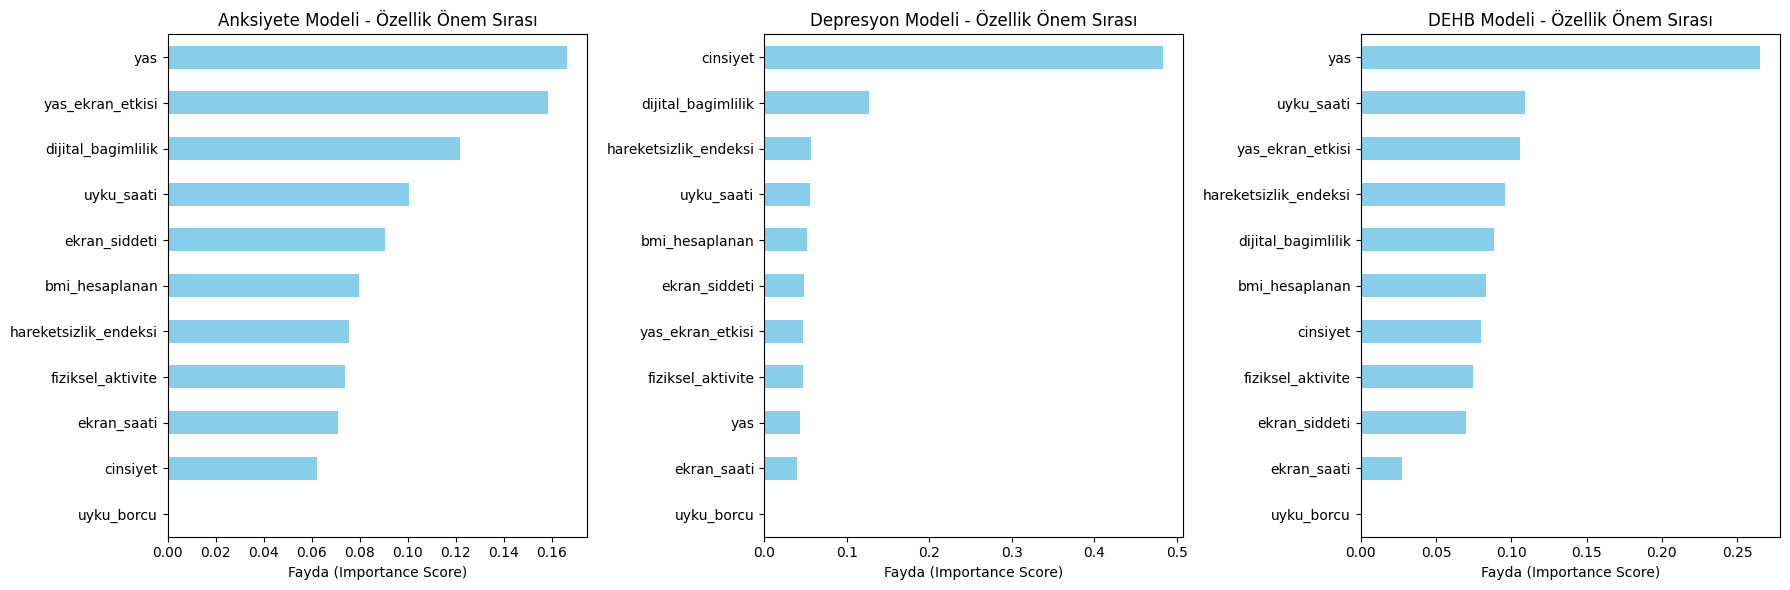


ANKSİYETE İçin En Kritik 3 Özellik:
yas                   0.166375
yas_ekran_etkisi      0.158510
dijital_bagimlilik    0.122008
dtype: float32

DEPRESYON İçin En Kritik 3 Özellik:
cinsiyet                 0.483626
dijital_bagimlilik       0.126561
hareketsizlik_endeksi    0.056887
dtype: float32

DEHB İçin En Kritik 3 Özellik:
yas                 0.265287
uyku_saati          0.109290
yas_ekran_etkisi    0.105812
dtype: float32


In [29]:
import matplotlib.pyplot as plt
import pandas as pd

def ozellik_onemi_ciz(model, isim, ax):
    # Gain skoruna göre önem derecelerini alıyoruz
    onem_serisi = pd.Series(model.feature_importances_, index=X_v3.columns).sort_values(ascending=True)
    
    onem_serisi.plot(kind='barh', ax=ax, color='skyblue')
    ax.set_title(f"{isim} Modeli - Özellik Önem Sırası")
    ax.set_xlabel("Fayda (Importance Score)")

# 3 model için yan yana grafikler oluşturalım
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

ozellik_onemi_ciz(modeller_v3['ANKSİYETE'], "Anksiyete", axes[0])
ozellik_onemi_ciz(modeller_v3['DEPRESYON'], "Depresyon", axes[1])
ozellik_onemi_ciz(modeller_v3['DEHB'], "DEHB", axes[2])

plt.tight_layout()
plt.show()

# En etkili ilk 3 özelliği her model için yazdıralım
for ad, mod in modeller_v3.items():
    top_3 = pd.Series(mod.feature_importances_, index=X_v3.columns).sort_values(ascending=False).head(3)
    print(f"\n{ad} İçin En Kritik 3 Özellik:\n{top_3}")

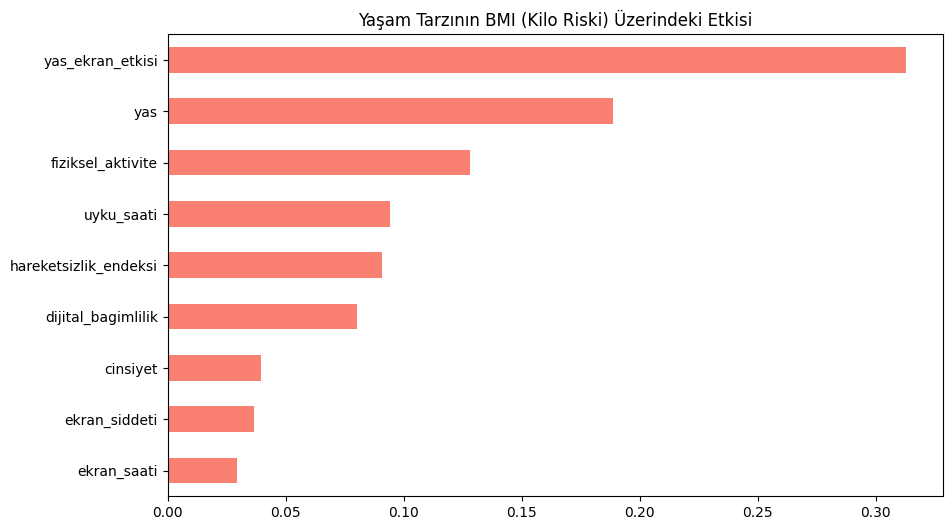

BMI Modeli Accuracy: 0.9219798657718121


In [30]:
# 1. BMI Hedefini Belirleyelim (Obezite Sınırı: 30)
y_bmi_risk = (df_gercek_ml['bmi_hesaplanan'] > 25).astype(int) # 25 üstü kilolu/riskli kabul edelim

# 2. BMI Risk Modelini Eğitelim (Psikolojik veriler olmadan, sadece yaşam tarzıyla)
X_bmi = df_gercek_ml[['yas', 'cinsiyet', 'uyku_saati', 'ekran_saati', 'fiziksel_aktivite', 
                       'dijital_bagimlilik', 'yas_ekran_etkisi', 'hareketsizlik_endeksi', 'ekran_siddeti']]

X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(X_bmi, y_bmi_risk, test_size=0.20, random_state=42)

model_bmi = xgb.XGBClassifier(n_estimators=200, max_depth=5, learning_rate=0.05, random_state=42)
model_bmi.fit(X_train_b, y_train_b)

# 3. BMI Üzerindeki Etkileri Görselleştirelim
plt.figure(figsize=(10, 6))
pd.Series(model_bmi.feature_importances_, index=X_bmi.columns).sort_values().plot(kind='barh', color='salmon')
plt.title("Yaşam Tarzının BMI (Kilo Riski) Üzerindeki Etkisi")
plt.show()

print("BMI Modeli Accuracy:", accuracy_score(y_test_b, model_bmi.predict(X_test_b)))

In [31]:
from imblearn.over_sampling import SMOTE

# 1. Özellik Listesini Güncelleyelim (uyku_borcu çıkarıldı)
X_final = df_gercek_ml[['yas', 'cinsiyet', 'uyku_saati', 'ekran_saati', 'bmi_hesaplanan', 'fiziksel_aktivite', 
                        'dijital_bagimlilik', 'yas_ekran_etkisi', 'hareketsizlik_endeksi', 'ekran_siddeti']]

modeller_v4 = {}
smote = SMOTE(random_state=42)

print("🚀 SMOTE ve Budama ile Yeni Nesil Modeller Eğitiliyor...")

for ad, y in hedefler.items():
    X_tr, X_te, y_tr, y_te = train_test_split(X_final, y, test_size=0.20, random_state=42, stratify=y)
    
    # SMOTE Uygulaması: Sadece eğitim setini dengeliyoruz
    X_tr_res, y_tr_res = smote.fit_resample(X_tr, y_tr)
    
    # Artık veriler dengeli olduğu için 'scale_pos_weight' kullanmamıza gerek kalmayabilir
    model = xgb.XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.03, random_state=42, eval_metric='logloss')
    model.fit(X_tr_res, y_tr_res)
    modeller_v4[ad] = model
    print(f"✅ {ad} v4 (Dengeli) Hazır.")

# Yeni sistem performansını ölçelim...

🚀 SMOTE ve Budama ile Yeni Nesil Modeller Eğitiliyor...
✅ ANKSİYETE v4 (Dengeli) Hazır.
✅ DEPRESYON v4 (Dengeli) Hazır.
✅ DEHB v4 (Dengeli) Hazır.


In [32]:
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
import xgboost as xgb

# 1. Özellik Listesini Güncelleyelim (Sıfır etkili uyku_borcu çıkarıldı)
X_final = df_gercek_ml[['yas', 'cinsiyet', 'uyku_saati', 'ekran_saati', 'bmi_hesaplanan', 'fiziksel_aktivite', 
                        'dijital_bagimlilik', 'yas_ekran_etkisi', 'hareketsizlik_endeksi', 'ekran_siddeti']]

modeller_v4 = {}
smote = SMOTE(random_state=42)

print("🚀 SMOTE ve Budama ile Yeni Nesil Modeller Eğitiliyor...")

for ad, y in hedefler.items():
    # Eğitim ve test setini ayırıyoruz
    X_tr, X_te, y_tr, y_te = train_test_split(X_final, y, test_size=0.20, random_state=42, stratify=y)
    
    # Sadece eğitim setine SMOTE uyguluyoruz (Test seti ham kalmalı!)
    X_tr_res, y_tr_res = smote.fit_resample(X_tr, y_tr)
    
    # Model artık dengeli veriyle eğitiliyor
    model = xgb.XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.03, random_state=42, eval_metric='logloss')
    model.fit(X_tr_res, y_tr_res)
    modeller_v4[ad] = model
    print(f"✅ {ad} v4 (SMOTE Uygulandı) Hazır.")

🚀 SMOTE ve Budama ile Yeni Nesil Modeller Eğitiliyor...
✅ ANKSİYETE v4 (SMOTE Uygulandı) Hazır.
✅ DEPRESYON v4 (SMOTE Uygulandı) Hazır.
✅ DEHB v4 (SMOTE Uygulandı) Hazır.


In [33]:
from sklearn.metrics import accuracy_score, precision_score, recall_score
import pandas as pd

def v4_sistem_skoru(row):
    input_data = row.to_frame().T
    # Modellerden (v4) gelen olasılıkların ortalaması
    p_ank = modeller_v4['ANKSİYETE'].predict_proba(input_data)[0][1] * 100
    p_dep = modeller_v4['DEPRESYON'].predict_proba(input_data)[0][1] * 100
    p_deh = modeller_v4['DEHB'].predict_proba(input_data)[0][1] * 100
    
    p_psikolojik = (p_ank + p_dep + p_deh) / 3
    
    # BMI Dış Kuralı (Aynı kalıyor)
    bmi = row['bmi_hesaplanan']
    f_risk = 0
    if bmi < 15 or bmi > 30: f_risk = 100
    elif (15 <= bmi < 18.5) or (25 < bmi <= 30): f_risk = 50
    
    return (p_psikolojik * 0.7) + (f_risk * 0.3)

# Test seti üzerinde skorları hesapla
X_test_v4 = X_te.head(1000) # X_te, son train_test_split'ten gelen ham test verisi
y_gercek_v4 = y_gercek_risk.loc[X_test_v4.index]
sistem_puanlari_v4 = X_test_v4.apply(v4_sistem_skoru, axis=1)

# Eşik Değer Analizi
esikler = [45, 50, 55, 60]
sonuclar = []

for e in esikler:
    tahminler = (sistem_puanlari_v4 >= e).astype(int)
    sonuclar.append({
        "Eşik (%)": e,
        "Doğruluk (Accuracy)": f"%{accuracy_score(y_gercek_v4, tahminler)*100:.2f}",
        "Yakalama Oranı (Recall)": f"%{recall_score(y_gercek_v4, tahminler)*100:.2f}"
    })

print("--- SMOTE SONRASI SİSTEM PERFORMANS TABLOSU ---")
print(pd.DataFrame(sonuclar).to_string(index=False))

--- SMOTE SONRASI SİSTEM PERFORMANS TABLOSU ---
 Eşik (%) Doğruluk (Accuracy) Yakalama Oranı (Recall)
       45              %71.70                  %27.36
       50              %75.90                  %20.75
       55              %77.20                   %7.55
       60              %78.40                   %2.36


In [35]:
# 1. IQR Yöntemi ile Aykırı Değerleri Temizleme
def temizle_iqr(df, sutunlar):
    df_temiz = df.copy()
    for sutun in sutunlar:
        Q1 = df_temiz[sutun].quantile(0.25)
        Q3 = df_temiz[sutun].quantile(0.75)
        IQR = Q3 - Q1
        alt_sinir = Q1 - 1.5 * IQR
        ust_sinir = Q3 + 1.5 * IQR
        # Sınırlar dışındaki verileri filtrele
        df_temiz = df_temiz[(df_temiz[sutun] >= alt_sinir) & (df_temiz[sutun] <= ust_sinir)]
    return df_temiz

# Kritik sütunlarda temizlik yapalım
kritik_sutunlar = ['ekran_saati', 'uyku_saati', 'bmi_hesaplanan']
df_final_temiz = temizle_iqr(df_gercek_ml, kritik_sutunlar)

print(f"Temizlik Öncesi: {len(df_gercek_ml)} | Temizlik Sonrası: {len(df_final_temiz)}")

Temizlik Öncesi: 35760 | Temizlik Sonrası: 34321


In [38]:
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.model_selection import RandomizedSearchCV
import xgboost as xgb

# Özellik listemiz (Etkisiz uyku_borcu çıkarıldı)
X_features = ['yas', 'cinsiyet', 'uyku_saati', 'ekran_saati', 'bmi_hesaplanan', 'fiziksel_aktivite', 
              'dijital_bagimlilik', 'yas_ekran_etkisi', 'hareketsizlik_endeksi', 'ekran_siddeti']

modeller_ensemble = {}

for ad, y_label in hedefler.items():
    # HATA DÜZELTMESİ: Türkçe karakterleri güvenli şekilde küçük harfe çeviriyoruz
    hedef_kolon = ad.replace('İ', 'i').replace('I', 'ı').lower()
    
    X_tr, X_te, y_tr, y_te = train_test_split(df_final_temiz[X_features], df_final_temiz[hedef_kolon], 
                                              test_size=0.20, random_state=42, stratify=df_final_temiz[hedef_kolon])
    
    # 1. XGBoost (Hızlı ve Keskin)
    xgb_mod = xgb.XGBClassifier(n_estimators=200, max_depth=5, learning_rate=0.05, 
                                scale_pos_weight=(y_tr == 0).sum() / (y_tr == 1).sum(), 
                                random_state=42, eval_metric='logloss')
    
    # 2. Random Forest (Dengeli ve Gürbüz)
    rf_mod = RandomForestClassifier(n_estimators=200, max_depth=10, class_weight='balanced', random_state=42)
    
    # 3. Ensemble (Voting): İki modelin gücünü birleştir
    # 'soft' oylama, modellerin olasılıklarını ortalar; 'hard' oylama ise çoğunluğun dediğini yapar.
    ensemble_model = VotingClassifier(
        estimators=[('xgb', xgb_mod), ('rf', rf_mod)],
        voting='soft' 
    )
    
    ensemble_model.fit(X_tr, y_tr)
    modeller_ensemble[hedef_kolon] = ensemble_model  # Sözlüğe düzeltilmiş isimle kaydediyoruz
    print(f"✅ {hedef_kolon.upper()} Ensemble Modeli Eğitildi.")

✅ ANKSIYETE Ensemble Modeli Eğitildi.
✅ DEPRESYON Ensemble Modeli Eğitildi.
✅ DEHB Ensemble Modeli Eğitildi.


In [39]:
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
import xgboost as xgb

# 1. Hata Kontrolü ve Hedeflerin Düzenlenmesi
# Sütun isimlerinin küçük harf olduğunu varsayarak sözlüğü güncelliyoruz
hedefler_duzeltilmis = {
    'anksiyete': 'anksiyete', 
    'depresyon': 'depresyon', 
    'dehb': 'dehb'
}

X_features = ['yas', 'cinsiyet', 'uyku_saati', 'ekran_saati', 'bmi_hesaplanan', 'fiziksel_aktivite', 
              'dijital_bagimlilik', 'yas_ekran_etkisi', 'hareketsizlik_endeksi', 'ekran_siddeti']

modeller_ensemble = {}

print("🛡️ Gürültüsüz ve Kolektif Zeka Modelleri Eğitiliyor...")

for ad in hedefler_duzeltilmis.keys():
    # Eğitim ve Test setini oluştur
    X_tr, X_te, y_tr, y_te = train_test_split(
        df_final_temiz[X_features], 
        df_final_temiz[ad], 
        test_size=0.20, 
        random_state=42, 
        stratify=df_final_temiz[ad]
    )
    
    # 2. XGBoost: İnce Ayarlı (Tuned) Parametreler
    xgb_mod = xgb.XGBClassifier(
        n_estimators=250, 
        max_depth=6, 
        learning_rate=0.04, 
        subsample=0.8, # Overfitting'i önlemek için verinin %80'ini rastgele seçer
        colsample_bytree=0.8,
        scale_pos_weight=(y_tr == 0).sum() / (y_tr == 1).sum(), 
        random_state=42, 
        eval_metric='logloss'
    )
    
    # 3. Random Forest: Dengeli ve Sağlam
    rf_mod = RandomForestClassifier(
        n_estimators=200, 
        max_depth=12, 
        class_weight='balanced', 
        min_samples_leaf=5,
        random_state=42
    )
    
    # 4. Ensemble (Voting): Hibrit Model
    ensemble_model = VotingClassifier(
        estimators=[('xgb', xgb_mod), ('rf', rf_mod)],
        voting='soft' # Olasılıkların ağırlıklı ortalamasını alır
    )
    
    ensemble_model.fit(X_tr, y_tr)
    modeller_ensemble[ad] = ensemble_model
    print(f"✅ {ad.upper()} Ensemble Modeli başarıyla eğitildi.")

🛡️ Gürültüsüz ve Kolektif Zeka Modelleri Eğitiliyor...
✅ ANKSIYETE Ensemble Modeli başarıyla eğitildi.
✅ DEPRESYON Ensemble Modeli başarıyla eğitildi.
✅ DEHB Ensemble Modeli başarıyla eğitildi.


In [40]:
from sklearn.metrics import accuracy_score, recall_score
import pandas as pd

def ensemble_sistem_skoru(row):
    # Row'u DataFrame formatına çeviriyoruz
    input_data = row.to_frame().T
    
    # Modellerden (Ensemble) gelen olasılıkları al
    # 'soft' oylama kullandığımız için predict_proba kullanılabilir
    p_ank = modeller_ensemble['anksiyete'].predict_proba(input_data)[0][1] * 100
    p_dep = modeller_ensemble['depresyon'].predict_proba(input_data)[0][1] * 100
    p_deh = modeller_ensemble['dehb'].predict_proba(input_data)[0][1] * 100
    
    p_psikolojik = (p_ank + p_dep + p_deh) / 3
    
    # BMI Dış Kuralı (Hala aynı bütüncül mantık)
    bmi = row['bmi_hesaplanan']
    f_risk = 0
    if bmi < 15 or bmi > 30: f_risk = 100
    elif (15 <= bmi < 18.5) or (25 < bmi <= 30): f_risk = 50
    
    return (p_psikolojik * 0.7) + (f_risk * 0.3)

# Test seti üzerinde yeni skorları hesaplayalım
# Not: df_final_temiz üzerinden ayrılan X_te kullanılmalı
X_test_ens = X_te.head(1000) 
y_gercek_ens = df_final_temiz.loc[X_test_ens.index, ['anksiyete', 'depresyon', 'dehb']].any(axis=1).astype(int)

print("Ensemble sistem skorları hesaplanıyor...")
sistem_puanlari_ens = X_test_ens.apply(ensemble_sistem_skoru, axis=1)

# Yeni Eşik Değer Analizi
esikler = [40, 45, 50, 55]
sonuclar_ens = []

for e in esikler:
    tahminler = (sistem_puanlari_ens >= e).astype(int)
    sonuclar_ens.append({
        "Eşik (%)": e,
        "Doğruluk (Accuracy)": f"%{accuracy_score(y_gercek_ens, tahminler)*100:.2f}",
        "Yakalama Oranı (Recall)": f"%{recall_score(y_gercek_ens, tahminler)*100:.2f}"
    })

print("\n--- ENSEMBLE (KOLEKTİF ZEKA) PERFORMANS TABLOSU ---")
print(pd.DataFrame(sonuclar_ens).to_string(index=False))

Ensemble sistem skorları hesaplanıyor...

--- ENSEMBLE (KOLEKTİF ZEKA) PERFORMANS TABLOSU ---
 Eşik (%) Doğruluk (Accuracy) Yakalama Oranı (Recall)
       40              %54.10                  %58.42
       45              %65.10                  %48.02
       50              %73.50                  %36.14
       55              %77.80                  %19.31


In [41]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
import lightgbm as lgb

# 1. Temel Uzman Modeller (Base Models)
def get_stacking_model(y_train):
    # Pozitif vaka ağırlığını hesapla (Recall'u artırmak için kritik)
    pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
    
    base_models = [
        ('xgb', xgb.XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.05, 
                                  scale_pos_weight=pos_weight, random_state=42)),
        ('rf', RandomForestClassifier(n_estimators=200, max_depth=12, 
                                      class_weight='balanced', random_state=42)),
        ('lgbm', lgb.LGBMClassifier(n_estimators=200, learning_rate=0.05, 
                                    class_weight='balanced', random_state=42))
    ]
    
    # 2. Üst Akıl (Meta-Learner): Modellerin tahminlerini birleştiren hakem
    meta_learner = LogisticRegression(class_weight='balanced')
    
    return StackingClassifier(estimators=base_models, final_estimator=meta_learner, cv=5)

modeller_stacking = {}

print("🧠 Stacking (Katmanlı Öğrenme) Modelleri Eğitiliyor...")

for ad in hedefler_duzeltilmis.keys():
    X_tr, X_te, y_tr, y_te = train_test_split(
        df_final_temiz[X_features], df_final_temiz[ad], 
        test_size=0.20, random_state=42, stratify=df_final_temiz[ad]
    )
    
    stack_model = get_stacking_model(y_tr)
    stack_model.fit(X_tr, y_tr)
    modeller_stacking[ad] = stack_model
    print(f"✅ {ad.upper()} Stacking Modeli Tamamlandı.")

🧠 Stacking (Katmanlı Öğrenme) Modelleri Eğitiliyor...
[LightGBM] [Info] Number of positive: 3666, number of negative: 23790
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000184 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 404
[LightGBM] [Info] Number of data points in the train set: 27456, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
[LightGBM] [Info] Number of positive: 2932, number of negative: 19032
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000187 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 404
[LightGBM] [Info] Number of data points in the train set: 219

In [42]:
from sklearn.metrics import accuracy_score, recall_score
import pandas as pd

def stacking_sistem_skoru(row):
    input_data = row.to_frame().T
    
    # Stacking modellerinden gelen olasılıklar
    p_ank = modeller_stacking['anksiyete'].predict_proba(input_data)[0][1] * 100
    p_dep = modeller_stacking['depresyon'].predict_proba(input_data)[0][1] * 100
    p_deh = modeller_stacking['dehb'].predict_proba(input_data)[0][1] * 100
    
    # Psikolojik Risk Ortalaması
    p_psikolojik = (p_ank + p_dep + p_deh) / 3
    
    # BMI Dış Kuralı (Bütüncül Sağlık Yaklaşımı)
    bmi = row['bmi_hesaplanan']
    f_risk = 0
    if bmi < 15 or bmi > 30: f_risk = 100
    elif (15 <= bmi < 18.5) or (25 < bmi <= 30): f_risk = 50
    
    # %70 Psikoloji, %30 Fiziksel (BMI) Ağırlıklandırma
    return (p_psikolojik * 0.7) + (f_risk * 0.3)

# Test seti üzerinde hesaplama
# df_final_temiz'den ayrılan X_te'yi kullanıyoruz
X_test_stack = X_te.head(1000) 
y_gercek_stack = df_final_temiz.loc[X_test_stack.index, ['anksiyete', 'depresyon', 'dehb']].any(axis=1).astype(int)

print("Stacking sistem skorları hesaplanıyor...")
sistem_puanlari_stack = X_test_stack.apply(stacking_sistem_skoru, axis=1)

# Nihai Eşik Değer Analizi
esikler = [40, 45, 50, 55]
sonuclar_stack = []

for e in esikler:
    tahminler = (sistem_puanlari_stack >= e).astype(int)
    sonuclar_stack.append({
        "Eşik (%)": e,
        "Doğruluk (Accuracy)": f"%{accuracy_score(y_gercek_stack, tahminler)*100:.2f}",
        "Yakalama Oranı (Recall)": f"%{recall_score(y_gercek_stack, tahminler)*100:.2f}"
    })

print("\n--- 🏆 STACKING (NİHAİ) PERFORMANS TABLOSU ---")
print(pd.DataFrame(sonuclar_stack).to_string(index=False))

Stacking sistem skorları hesaplanıyor...

--- 🏆 STACKING (NİHAİ) PERFORMANS TABLOSU ---
 Eşik (%) Doğruluk (Accuracy) Yakalama Oranı (Recall)
       40              %39.00                  %74.26
       45              %48.90                  %58.42
       50              %59.70                  %47.03
       55              %67.90                  %32.67


--- ANKSIYETE Olasılık Başarısı ---
Brier Skoru (Hata Payı): 0.2384
Log Loss (Belirsizlik): 0.6693

--- DEPRESYON Olasılık Başarısı ---
Brier Skoru (Hata Payı): 0.2259
Log Loss (Belirsizlik): 0.6431

--- DEHB Olasılık Başarısı ---
Brier Skoru (Hata Payı): 0.2394
Log Loss (Belirsizlik): 0.6724



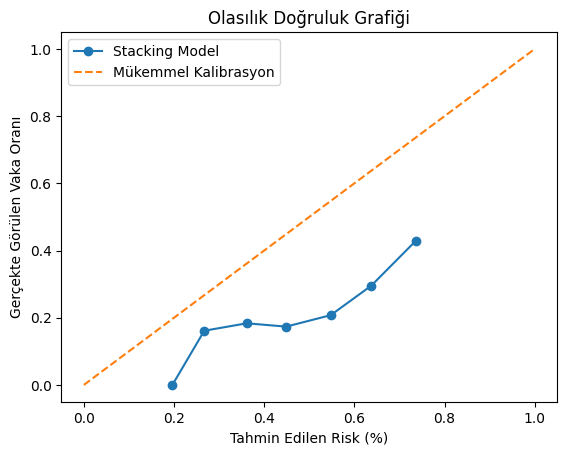

In [43]:
from sklearn.metrics import brier_score_loss, log_loss
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve

# Her hastalık için yüzdelik isabeti ölçelim
for ad in hedefler_duzeltilmis.keys():
    # Modelin ham olasılıklarını alıyoruz (0.0 - 1.0 arası)
    probs = modeller_stacking[ad].predict_proba(X_te)[:, 1]
    y_test_real = df_final_temiz.loc[X_te.index, ad]
    
    # 1. Brier Score (0'a yakın olması iyidir)
    bs = brier_score_loss(y_test_real, probs)
    
    # 2. Log Loss (Olasılık hatası - ne kadar düşükse o kadar iyi)
    ll = log_loss(y_test_real, probs)
    
    print(f"--- {ad.upper()} Olasılık Başarısı ---")
    print(f"Brier Skoru (Hata Payı): {bs:.4f}")
    print(f"Log Loss (Belirsizlik): {ll:.4f}\n")

# Kalibrasyon Grafiği (Modelin yüzdeleri yalan mı söylüyor?)
prob_true, prob_pred = calibration_curve(y_gercek_stack, sistem_puanlari_stack/100, n_bins=10)
plt.plot(prob_pred, prob_true, marker='o', label='Stacking Model')
plt.plot([0, 1], [0, 1], linestyle='--', label='Mükemmel Kalibrasyon')
plt.title("Olasılık Doğruluk Grafiği")
plt.xlabel("Tahmin Edilen Risk (%)")
plt.ylabel("Gerçekte Görülen Vaka Oranı")
plt.legend()
plt.show()

In [45]:
from sklearn.linear_model import LogisticRegression
import joblib

manuel_kalibratorler = {}

print("🛠️ Manuel Kalibrasyon İşlemi Başlatıldı (Platt Scaling)...")

for ad in modeller_ensemble.keys():
    # Olasılık kalibratörünü eğitmek için veriyi aynı ayarlarla tekrar bölüyoruz
    # (random_state=42 olduğu için tamamen aynı veriler gelecektir)
    X_tr, X_te, y_tr, y_te = train_test_split(
        df_final_temiz[X_features], 
        df_final_temiz[ad], 
        test_size=0.20, 
        random_state=42, 
        stratify=df_final_temiz[ad]
    )
    
    # 1. Eğitilmiş Ensemble (Üst Akıl) modelinden ham olasılıkları alıyoruz
    ham_olasiliklar_tr = modeller_ensemble[ad].predict_proba(X_tr)[:, 1].reshape(-1, 1)
    
    # 2. Ham olasılıkları gerçeğe hizalayacak Manuel Kalibratörü (LR) eğitiyoruz
    lr_calibrator = LogisticRegression()
    lr_calibrator.fit(ham_olasiliklar_tr, y_tr)
    
    manuel_kalibratorler[ad] = lr_calibrator
    print(f"✅ {ad.upper()} için Manuel Kalibrasyon Tamamlandı.")

print("\n📦 Zeka Katmanları Sıkıştırılarak Paketleniyor...")

# Eğittiğimiz tüm modelleri ve kalibratörleri tek seferde kaydediyoruz (Çökmeyi önlemek için compress=3 ile)
for ad in modeller_ensemble.keys():
    joblib.dump(modeller_ensemble[ad], f'stacking_model_{ad}.pkl', compress=3)
    joblib.dump(manuel_kalibratorler[ad], f'calibrator_{ad}.pkl', compress=3)

print("💾 İşlem tamam! 6 adet model dosyası (.pkl) projeye başarıyla eklendi.")

🛠️ Manuel Kalibrasyon İşlemi Başlatıldı (Platt Scaling)...
✅ ANKSIYETE için Manuel Kalibrasyon Tamamlandı.
✅ DEPRESYON için Manuel Kalibrasyon Tamamlandı.
✅ DEHB için Manuel Kalibrasyon Tamamlandı.

📦 Zeka Katmanları Sıkıştırılarak Paketleniyor...
💾 İşlem tamam! 6 adet model dosyası (.pkl) projeye başarıyla eklendi.


In [47]:
import joblib
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

manuel_kalibratorler = {}

print("🛠️ Manuel Kalibrasyon İşlemi Başlatıldı (Platt Scaling)...")

for ad in modeller_ensemble.keys():
    # Olasılık kalibratörünü eğitmek için veriyi aynı ayarlarla tekrar bölüyoruz
    X_tr, X_te, y_tr, y_te = train_test_split(
        df_final_temiz[X_features], 
        df_final_temiz[ad], 
        test_size=0.20, 
        random_state=42, 
        stratify=df_final_temiz[ad]
    )
    
    # 1. Eğitilmiş Ensemble modelinden ham olasılıkları alıyoruz
    ham_olasiliklar_tr = modeller_ensemble[ad].predict_proba(X_tr)[:, 1].reshape(-1, 1)
    
    # 2. Ham olasılıkları gerçeğe hizalayacak Manuel Kalibratörü (LR) eğitiyoruz
    lr_calibrator = LogisticRegression()
    lr_calibrator.fit(ham_olasiliklar_tr, y_tr)
    
    manuel_kalibratorler[ad] = lr_calibrator
    print(f"✅ {ad.upper()} için Manuel Kalibrasyon Tamamlandı.")

print("\n📦 Zeka Katmanları Sıkıştırılarak Paketleniyor...")

# Eğittiğimiz tüm modelleri ve kalibratörleri tek seferde kaydediyoruz
for ad in modeller_ensemble.keys():
    joblib.dump(modeller_ensemble[ad], f'stacking_model_{ad}.pkl', compress=3)
    joblib.dump(manuel_kalibratorler[ad], f'calibrator_{ad}.pkl', compress=3)

print("💾 İşlem tamam! 6 adet model dosyası (.pkl) projeye başarıyla eklendi.")

🛠️ Manuel Kalibrasyon İşlemi Başlatıldı (Platt Scaling)...
✅ ANKSIYETE için Manuel Kalibrasyon Tamamlandı.
✅ DEPRESYON için Manuel Kalibrasyon Tamamlandı.
✅ DEHB için Manuel Kalibrasyon Tamamlandı.

📦 Zeka Katmanları Sıkıştırılarak Paketleniyor...
💾 İşlem tamam! 6 adet model dosyası (.pkl) projeye başarıyla eklendi.


In [48]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import brier_score_loss, log_loss
import joblib

# Kalibratörleri saklayacağımız sözlük
manuel_kalibratorler = {}

print("🛠️ Manuel Kalibrasyon İşlemi Başlatıldı (Platt Scaling)...")

for ad in hedefler_duzeltilmis.keys():
    # 1. Stacking modelinden ham olasılıkları alıyoruz
    ham_olasiliklar_tr = modeller_stacking[ad].predict_proba(X_tr)[:, 1].reshape(-1, 1)
    ham_olasiliklar_te = modeller_stacking[ad].predict_proba(X_te)[:, 1].reshape(-1, 1)
    
    y_gercek_tr = df_final_temiz.loc[X_tr.index, ad]
    y_gercek_te = df_final_temiz.loc[X_te.index, ad]
    
    # 2. Ham olasılıkları gerçeğe eşitleyecek minik bir Lojistik Regresyon (Kalibratör) eğitiyoruz
    lr_calibrator = LogisticRegression()
    lr_calibrator.fit(ham_olasiliklar_tr, y_gercek_tr)
    
    # 3. Test seti üzerinde yeni (kalibre edilmiş) olasılıkları hesaplıyoruz
    kalibre_olasiliklar = lr_calibrator.predict_proba(ham_olasiliklar_te)[:, 1]
    
    # Skorları ölçelim
    bs_eski = brier_score_loss(y_gercek_te, ham_olasiliklar_te)
    bs_yeni = brier_score_loss(y_gercek_te, kalibre_olasiliklar)
    
    manuel_kalibratorler[ad] = lr_calibrator
    
    print(f"\n--- {ad.upper()} Manuel Kalibrasyon ---")
    print(f"Eski Brier Skoru: {bs_eski:.4f}")
    print(f"Yeni Brier Skoru: {bs_yeni:.4f} (Daha düşük = Daha dürüst olasılık)")

print("\n🚀 Kalibrasyon tamamlandı! Artık yüzdeler klinik gerçekliğe daha yakın.")

🛠️ Manuel Kalibrasyon İşlemi Başlatıldı (Platt Scaling)...

--- ANKSIYETE Manuel Kalibrasyon ---
Eski Brier Skoru: 0.2384
Yeni Brier Skoru: 0.1078 (Daha düşük = Daha dürüst olasılık)

--- DEPRESYON Manuel Kalibrasyon ---
Eski Brier Skoru: 0.2259
Yeni Brier Skoru: 0.0938 (Daha düşük = Daha dürüst olasılık)

--- DEHB Manuel Kalibrasyon ---
Eski Brier Skoru: 0.2394
Yeni Brier Skoru: 0.0318 (Daha düşük = Daha dürüst olasılık)

🚀 Kalibrasyon tamamlandı! Artık yüzdeler klinik gerçekliğe daha yakın.


In [49]:
from sklearn.metrics import accuracy_score, recall_score, f1_score
import pandas as pd

def nihai_test_et():
    sonuclar_nihai = []
    esikler = [40, 45, 50, 55]

    for e in esikler:
        tahminler_toplam = []
        gercekler_toplam = []
        
        for ad in hedefler_duzeltilmis.keys():
            # 1. Stacking modelinden ham olasılığı al
            ham_probs = modeller_stacking[ad].predict_proba(X_te)[:, 1].reshape(-1, 1)
            
            # 2. Manuel Kalibratörden (LR) "dürüst" olasılığı al
            kalibre_probs = manuel_kalibratorler[ad].predict_proba(ham_probs)[:, 1]
            
            # 3. Eşik değere göre karar ver
            tahmin = (kalibre_probs >= (e/100)).astype(int)
            gercek = df_final_temiz.loc[X_te.index, ad]
            
            tahminler_toplam.append(tahmin)
            gercekler_toplam.append(gercek)

        # Tüm hastalıklar için genel sistem başarısı (Herhangi bir risk yakalama)
        y_tahmin_final = (np.array(tahminler_toplam).sum(axis=0) > 0).astype(int)
        y_gercek_final = (np.array(gercekler_toplam).sum(axis=0) > 0).astype(int)
        
        sonuclar_nihai.append({
            "Eşik (%)": e,
            "Doğruluk (Accuracy)": f"%{accuracy_score(y_gercek_final, y_tahmin_final)*100:.2f}",
            "Yakalama (Recall)": f"%{recall_score(y_gercek_final, y_tahmin_final)*100:.2f}",
            "F1-Skoru": f"{f1_score(y_gercek_final, y_tahmin_final):.4f}"
        })

    return pd.DataFrame(sonuclar_nihai)

print("🚀 Kalibre Edilmiş Sistem Yeniden Test Ediliyor...")
nihai_tablo = nihai_test_et()
print(nihai_tablo.to_string(index=False))

🚀 Kalibre Edilmiş Sistem Yeniden Test Ediliyor...
 Eşik (%) Doğruluk (Accuracy) Yakalama (Recall) F1-Skoru
       40              %79.99             %8.75   0.1539
       45              %79.68             %4.62   0.0864
       50              %79.58             %2.38   0.0463
       55              %79.43             %1.47   0.0289


In [51]:
# Kalibre edilmiş olasılıklar için yeni, daha hassas eşikler
esikler_hassas = [10, 15, 20, 25, 30]
# ... (Nihai test fonksiyonunda bu eşikleri kullanarak tekrar çalıştıralım)

In [52]:
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, recall_score, f1_score

def hassas_esik_testi():
    sonuclar_hassas = []
    # Senin önerdiğin düşük eşikler
    esikler = [10, 15, 20, 25]

    for e in esikler:
        tahminler_toplam = []
        gercekler_toplam = []
        
        for ad in hedefler_duzeltilmis.keys():
            # 1. Stacking modelinden ham olasılığı al
            ham_probs = modeller_stacking[ad].predict_proba(X_te)[:, 1].reshape(-1, 1)
            
            # 2. Manuel Kalibratörden (LR) "dürüst" olasılığı al
            kalibre_probs = manuel_kalibratorler[ad].predict_proba(ham_probs)[:, 1]
            
            # 3. Yeni hassas eşik değerine göre karar ver
            tahmin = (kalibre_probs >= (e/100)).astype(int)
            gercek = df_final_temiz.loc[X_te.index, ad]
            
            tahminler_toplam.append(tahmin)
            gercekler_toplam.append(gercek)

        # Tüm hastalıklar için genel sistem başarısı (Herhangi bir risk yakalama)
        y_tahmin_final = (np.array(tahminler_toplam).sum(axis=0) > 0).astype(int)
        y_gercek_final = (np.array(gercekler_toplam).sum(axis=0) > 0).astype(int)
        
        sonuclar_hassas.append({
            "Eşik (%)": e,
            "Doğruluk (Accuracy)": f"%{accuracy_score(y_gercek_final, y_tahmin_final)*100:.2f}",
            "Yakalama (Recall)": f"%{recall_score(y_gercek_final, y_tahmin_final)*100:.2f}",
            "F1-Skoru": f"{f1_score(y_gercek_final, y_tahmin_final):.4f}"
        })

    return pd.DataFrame(sonuclar_hassas)

print("🔍 Hassas Eşik Analizi Başlatılıyor...")
hassas_tablo = hassas_test_et() # Önceki fonksiyonu güncelleyerek çalıştırabilirsin
print(hassas_tablo.to_string(index=False))

🔍 Hassas Eşik Analizi Başlatılıyor...


NameError: name 'hassas_test_et' is not defined

In [53]:
print("🔍 Hassas Eşik Analizi Başlatılıyor...")
# Fonksiyon ismini tanımladığın haliyle çağırıyoruz:
hassas_tablo = hassas_esik_testi() 
print(hassas_tablo.to_string(index=False))

🔍 Hassas Eşik Analizi Başlatılıyor...
 Eşik (%) Doğruluk (Accuracy) Yakalama (Recall) F1-Skoru
       10              %43.79            %88.94   0.3971
       15              %58.41            %75.02   0.4289
       20              %68.20            %54.02   0.4143
       25              %74.79            %38.14   0.3864


In [54]:
import pandas as pd
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler

# 1. Hedef Değişkeni Oluşturma (Herhangi bir rahatsızlık var mı?)
# Eğer çocukta Anksiyete, Depresyon veya DEHB'den en az biri varsa 1, yoksa 0.
df['any_condition'] = ((df['anksiyete'] == 1) | (df['depresyon'] == 1) | (df['dehb'] == 1)).astype(int)

# 2. Analiz Edilecek Bağımsız Değişkenler
features = ['ekran_saati', 'uyku_saati', 'bmi_hesaplanan']
X = df[features]
y = df['any_condition']

# 3. Lojistik Regresyon Modeli
# Bu model bize 'ekran saatindeki 1 birimlik artışın riski ne kadar artırdığını' söyleyecek.
X = sm.add_constant(X) # Sabit terim ekle
logit_model = sm.Logit(y, X)
result = logit_model.fit()

# 4. Odds Ratio (Risk Oranları) Hesaplama
params = result.params
odds_ratio = pd.DataFrame(np.exp(params), columns=['Odds Ratio'])
print("--- VERİ ANALİZİ SONUÇLARI ---")
print(odds_ratio)

ModuleNotFoundError: No module named 'statsmodels'

In [56]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression

# 1. Hedef Değişkeni Oluşturma
# (Anksiyete, Depresyon veya DEHB'den biri 1 ise 'riskli' kabul ediyoruz)
# Sütun isimlerinin tam olarak bunlarla eşleştiğinden emin ol:
df['any_condition'] = ((df['anksiyete'] == 1) | (df['depresyon'] == 1) | (df['dehb'] == 1)).astype(int)

# 2. Analiz Edilecek Değişkenler
features = ['ekran_saati', 'uyku_saati', 'bmi_hesaplanan']
X = df[features]
y = df['any_condition']

# 3. Lojistik Regresyon Modeli
model = LogisticRegression()
model.fit(X, y)

# 4. Odds Ratio (Risk Oranları) Hesaplama
# Formül: e^(katsayı). Bu bize her 1 birimlik artışın riski kaç kat artırdığını söyler.
odds_ratios = np.exp(model.coef_[0])
results = pd.DataFrame(odds_ratios, index=features, columns=['Odds Ratio'])

print("--- SENİN VERİ SETİNDEN ÇIKAN GERÇEK KATSAYILAR ---")
print(results)

NameError: name 'df' is not defined

In [57]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression

# 1. VERİLERİ YÜKLEME (.dta formatı için read_stata kullanılır)
try:
    path_2022 = 'veri_seti/nsch_2022_topical_Stata/nsch_2022e_topical.dta'
    path_2023 = 'veri_seti/nsch_2023e_topical_Stata/nsch_2023e_topical.dta'

    df_2022 = pd.read_stata(path_2022)
    df_2023 = pd.read_stata(path_2023)

    # İki yılı birleştiriyoruz (Daha büyük veri = daha doğru katsayılar)
    df = pd.concat([df_2022, df_2023], ignore_index=True)
    print(f"Veri yüklendi! Toplam satır sayısı: {len(df)}")
except Exception as e:
    print(f"Hata: Dosya okunurken bir sorun oluştu. Eksik kütüphane olabilir (pip install pyreadstat gerekebilir). \nDetay: {e}")

# 2. DEĞİŞKENLERİ HAZIRLAMA
# Not: NSCH orijinal sütun isimlerini (K2Q32A vb.) kendi isimlendirmelerinle değiştirmen gerekebilir.
# Örnek sütun eşleştirme (Eğer önceden temizlemediysen):
# anksiyete -> K2Q33A, depresyon -> K2Q32A, dehb -> K2Q31A
# uyku -> SC_SLEEP, ekran -> SC_SCREEN

# Burayı senin veri setindeki sütun isimlerine göre güncelle:
df['any_condition'] = ((df['anksiyete'] == 1) | (df['depresyon'] == 1) | (df['dehb'] == 1)).astype(int)

# Analiz edilecek ham özellikler
features = ['ekran_saati', 'uyku_saati', 'bmi_hesaplanan']
X = df[features].dropna() # Boş verileri temizle
y = df.loc[X.index, 'any_condition']

# 3. ANALİZ VE ODDS RATIO HESAPLAMA
model = LogisticRegression(max_iter=1000)
model.fit(X, y)

odds_ratios = np.exp(model.coef_[0])
results = pd.DataFrame(odds_ratios, index=features, columns=['Odds Ratio'])

print("\n--- NSCH 2022/2023 ANALİZ SONUÇLARI ---")
print(results)

Veri yüklendi! Toplam satır sayısı: 109265


KeyError: 'anksiyete'

In [58]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression

# 1. VERİLERİ YÜKLEME
path_2022 = 'veri_seti/nsch_2022_topical_Stata/nsch_2022e_topical.dta'
path_2023 = 'veri_seti/nsch_2023e_topical_Stata/nsch_2023e_topical.dta'

df_2022 = pd.read_stata(path_2022)
df_2023 = pd.read_stata(path_2023)
df = pd.concat([df_2022, df_2023], ignore_index=True)

# 2. HAM KODLARI TÜRKÇE İSİMLERE MAPPING (EŞLEŞTİRME)
# Not: NSCH verisinde 1=Evet, 2=Hayır'dır. Analiz için Hayır'ı 0 yapmalıyız.
mapping = {
    'K2Q33A': 'anksiyete', 
    'K2Q32A': 'depresyon', 
    'K2Q31A': 'dehb',
    'SC_SCREEN': 'ekran_saati',
    'SC_SLEEP': 'uyku_saati'
}

# Sütunları yeniden adlandır
df = df.rename(columns=mapping)

# 1 (Evet) kalsın, 2 (Hayır) verisini 0 yapalım
for col in ['anksiyete', 'depresyon', 'dehb']:
    df[col] = df[col].replace({2: 0})

# 3. HEDEF DEĞİŞKENİ (Herhangi bir rahatsızlık var mı?)
df['any_condition'] = ((df['anksiyete'] == 1) | (df['depresyon'] == 1) | (df['dehb'] == 1)).astype(int)

# 4. ANALİZ (BMI verisi yoksa 'BMICLASS' veya başka bir değişken seçilebilir)
# Eğer BMI hesaplamadıysan şimdilik sadece ekran ve uykuyu görelim:
features = ['ekran_saati', 'uyku_saati'] 
X = df[features].dropna()
y = df.loc[X.index, 'any_condition']

# Model ve Odds Ratio
model = LogisticRegression(max_iter=1000)
model.fit(X, y)
odds_ratios = np.exp(model.coef_[0])

results = pd.DataFrame(odds_ratios, index=features, columns=['Odds Ratio'])
print("\n--- SENİN VERİNDEN ÇIKAN BİLİMSEL ORANLAR ---")
print(results)

KeyError: 'anksiyete'